# 3H — Hollow cabinet versus measurement versus massive cabinet

This final H-series notebook compares three radiation fields on one common
P1–P5 grid:

1. the final **hollow-cabinet** OpenMC result from Notebook 2H;
2. the **theory-assisted measured** AP field from Notebook 5;
3. the original **massive (solid-steel) cabinet** OpenMC result from Notebook 3.

For component $j\in\{n,\gamma,\mathrm{tot}\}$, the central comparison ratios
are

$$
R_{H/M,j}=\frac{\dot H^{(\mathrm{hollow})}_j}
                 {\widehat{\dot H}^{(\mathrm{measured})}_j},
\qquad
R_{S/M,j}=\frac{\dot H^{(\mathrm{massive})}_j}
                 {\widehat{\dot H}^{(\mathrm{measured})}_j},
$$

and the direct geometry effect is

$$
R_{H/S,j}=\frac{\dot H^{(\mathrm{hollow})}_j}
                 {\dot H^{(\mathrm{massive})}_j}.
$$

Notebook 5 used the massive Notebook 3 conversion field when converting the
detector indications to AP component estimates. Consequently, the two
simulation-to-measurement comparisons are **model-assisted consistency tests**,
not independent validations. No independence-assuming combined $z$ score is
reported. The direct hollow-to-massive ratio is the cleanest diagnostic of the
cabinet-air-layer effect; its uncertainty includes OpenMC batch statistics only.


# 1) Setup and comparison conventions

P1–P5 retain their established colours. Hollow simulations use dashed lines,
massive-cabinet simulations use solid lines, and measured estimates use point
markers. The two inclusive target-height intervals are $38$–$65$ cm and
$85$–$113$ cm, while exact target heights remain separate during interpolation
and plotting.

All simulation curves are interpolated only along the same P-position and exact
target-height curve. No nearest-direction substitution and no distance
extrapolation are allowed.


In [7]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, to_rgb
from matplotlib.lines import Line2D

try:
    from IPython.display import display
except ImportError:
    def display(*objects):
        for object_to_display in objects:
            print(object_to_display)


BASE_DIR = Path.cwd().resolve()
OUTPUT_DIR = BASE_DIR / "H3_hollow_vs_measurement_vs_massive_outputs"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
METADATA_DIR = OUTPUT_DIR / "metadata"

for directory in (OUTPUT_DIR, TABLE_DIR, FIGURE_DIR, METADATA_DIR):
    directory.mkdir(parents=True, exist_ok=True)


POSITION_SEQUENCE = ["P1", "P2", "P3", "P4", "P5"]
POSITION_ORDER = {
    position: index
    for index, position in enumerate(POSITION_SEQUENCE, start=1)
}
POSITION_COLORS = {
    "P1": "tab:blue",
    "P2": "tab:orange",
    "P3": "tab:green",
    "P4": "tab:red",
    "P5": "tab:purple",
}

MODEL_STYLES = {
    "hollow": {
        "label": "Hollow cabinet",
        "linestyle": "--",
        "linewidth": 1.65,
        "band_alpha": 0.10,
    },
    "massive": {
        "label": "Massive cabinet",
        "linestyle": "-",
        "linewidth": 1.45,
        "band_alpha": 0.055,
    },
}

ANALYSIS_HEIGHT_INTERVALS_CM = {
    "lower": (38.0, 65.0),
    "upper": (85.0, 113.0),
}
ANALYSIS_HEIGHT_INTERVAL_LABELS = {
    "lower": "Lower height interval (38–65 cm)",
    "upper": "Upper height interval (85–113 cm)",
}
HEIGHT_INTERVAL_ORDER = {"lower": 0, "upper": 1}

TARGET_KEY = ["position", "distance_cm", "height_cm"]
MATCH_ATOL_CM = 1.0e-9
ONE_SIDED_95_Z = 1.6448536269514722
DEFAULT_POSITION_LIMIT_CM = 1.0

COMPONENT_LABELS = {
    "neutron": "Neutron AP dose rate",
    "gamma": "Gamma AP dose rate",
    "total": "Total AP dose rate",
}
COMPONENT_MEASURED_COLUMNS = {
    "neutron": "measured_neutron_ap_component_uSv_h",
    "gamma": "measured_gamma_ap_component_uSv_h",
    "total": "measured_total_ap_estimate_uSv_h",
}
COMPONENT_MEASURED_U_COLUMNS = {
    "neutron": "u_measured_neutron_ap_component_uSv_h",
    "gamma": "u_measured_gamma_ap_component_uSv_h",
    "total": "u_measured_total_ap_estimate_uSv_h",
}
COMPONENT_MEASURED_AVAILABLE_COLUMNS = {
    "neutron": "neutron_component_available",
    "gamma": "gamma_component_available",
    "total": "total_estimate_available",
}

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 190)
pd.set_option("display.max_colwidth", 160)
plt.rcParams.update({
    "figure.dpi": 150,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
})

exported_figure_rows = []


def first_existing_project_file(candidates, label):
    for candidate in candidates:
        candidate = Path(candidate)
        if candidate.is_file():
            print(f"Using {label}: {candidate}")
            return candidate
    tried = "\n".join(f"  {Path(candidate)}" for candidate in candidates)
    raise FileNotFoundError(f"Could not find {label}. Tried:\n{tried}")


def require_columns(dataframe, columns, label):
    missing = [column for column in columns if column not in dataframe.columns]
    if missing:
        raise KeyError(
            f"{label} is missing required columns: {missing}. "
            f"Available columns: {dataframe.columns.tolist()}"
        )


def canonical_position(series):
    return series.astype(str).str.strip().str.upper()


def assign_analysis_height_interval(height_cm):
    height_cm = float(height_cm)
    for interval, (lower_cm, upper_cm) in ANALYSIS_HEIGHT_INTERVALS_CM.items():
        if lower_cm <= height_cm <= upper_cm:
            return interval
    return pd.NA


def lighten_color(color, amount):
    rgb = np.asarray(to_rgb(color), dtype=float)
    return tuple((1.0 - amount) * rgb + amount * np.ones(3))


def build_position_height_colors(dataframe):
    colors = {}
    for position in POSITION_SEQUENCE:
        heights = np.sort(
            dataframe.loc[dataframe["position"].eq(position), "height_cm"]
            .dropna().unique().astype(float)
        )
        if not len(heights):
            continue
        amounts = np.linspace(0.0, 0.58, len(heights))
        for height_cm, amount in zip(heights, amounts):
            colors[(position, float(height_cm))] = lighten_color(
                POSITION_COLORS[position], float(amount)
            )
    return colors


def save_figure(figure, filename_stem):
    png_path = FIGURE_DIR / f"{filename_stem}.png"
    pdf_path = FIGURE_DIR / f"{filename_stem}.pdf"
    figure.savefig(png_path, dpi=300, bbox_inches="tight")
    figure.savefig(pdf_path, bbox_inches="tight")
    exported_figure_rows.append({
        "stem": filename_stem,
        "png_path": str(png_path.resolve()),
        "pdf_path": str(pdf_path.resolve()),
    })


def show_save_close(figure, filename_stem):
    save_figure(figure, filename_stem)
    plt.show()
    plt.close(figure)


def plot_simulation_curve(
    axis, x, y, uncertainty, *, color, model, zorder=2,
):
    style = MODEL_STYLES[model]
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    uncertainty = np.asarray(uncertainty, dtype=float)
    valid = np.isfinite(x) & np.isfinite(y) & (y > 0.0)
    axis.plot(
        x,
        np.where(valid, y, np.nan),
        color=color,
        linestyle=style["linestyle"],
        linewidth=style["linewidth"],
        alpha=0.92,
        zorder=zorder,
    )
    band_valid = (
        valid
        & np.isfinite(uncertainty)
        & (uncertainty >= 0.0)
        & ((y - uncertainty) > 0.0)
    )
    if np.any(band_valid):
        axis.fill_between(
            x,
            y - uncertainty,
            y + uncertainty,
            where=band_valid,
            color=color,
            alpha=style["band_alpha"],
            linewidth=0.0,
            zorder=zorder - 1,
        )


def plot_measured_points(
    axis, x, y, uncertainty, *, color, marker="o", xerr=None, zorder=5,
):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    uncertainty = np.asarray(uncertainty, dtype=float)
    if xerr is None or not np.isfinite(float(xerr)):
        xerr = DEFAULT_POSITION_LIMIT_CM
    valid = (
        np.isfinite(x)
        & np.isfinite(y)
        & (y > 0.0)
        & np.isfinite(uncertainty)
        & (uncertainty >= 0.0)
    )
    regular = valid & ((y - uncertainty) > 0.0)
    zero_compatible = valid & ~regular
    if np.any(regular):
        axis.errorbar(
            x[regular],
            y[regular],
            xerr=np.full(regular.sum(), float(xerr)),
            yerr=uncertainty[regular],
            fmt=marker,
            linestyle="none",
            color=color,
            markerfacecolor="white",
            markeredgecolor=color,
            markeredgewidth=1.15,
            markersize=5.2,
            ecolor=color,
            elinewidth=0.9,
            capsize=2.5,
            zorder=zorder,
        )
    if np.any(zero_compatible):
        upper_95 = y[zero_compatible] + ONE_SIDED_95_Z * uncertainty[zero_compatible]
        axis.errorbar(
            x[zero_compatible],
            upper_95,
            xerr=np.full(zero_compatible.sum(), float(xerr)),
            fmt="v",
            linestyle="none",
            color=color,
            markerfacecolor="none",
            markeredgecolor=color,
            markeredgewidth=1.15,
            markersize=5.8,
            ecolor=color,
            elinewidth=0.9,
            capsize=2.5,
            zorder=zorder,
        )


def model_legend_handles():
    return [
        Line2D(
            [0], [0], color="black",
            linestyle=MODEL_STYLES["hollow"]["linestyle"],
            linewidth=MODEL_STYLES["hollow"]["linewidth"],
            label="Hollow simulation",
        ),
        Line2D(
            [0], [0], color="black",
            linestyle=MODEL_STYLES["massive"]["linestyle"],
            linewidth=MODEL_STYLES["massive"]["linewidth"],
            label="Massive simulation",
        ),
        Line2D(
            [0], [0], color="black", marker="o", linestyle="none",
            markerfacecolor="white", label="Theory-assisted measurement",
        ),
    ]


print("Notebook 3H setup completed.")
print(f"Working directory: {BASE_DIR}")
print(f"Output directory:  {OUTPUT_DIR}")


Notebook 3H setup completed.
Working directory: /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn
Output directory:  /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/H3_hollow_vs_measurement_vs_massive_outputs


# 2) Load and validate the three canonical hand-offs

The hollow and massive tables must contain neutron, gamma, and total AP dose
rates with their OpenMC batch-standard uncertainties. Notebook 5 supplies the
measurement-supported common target grid and the separately propagated
neutron, gamma, and total theory-assisted AP estimates.

The source date and AP irradiation geometry are compared when both simulation
metadata files are available. The common simulation nodes must retain identical
reference coordinates; otherwise a geometry comparison would be invalid.


In [8]:
HOLLOW_INPUT_PATH = first_existing_project_file(
    [
        BASE_DIR / "H2_hollow_cabinet_unified_outputs" / "tables"
        / "hollow_unified_simulated_radiation_field_final.csv",
        BASE_DIR / "H2_hollow_cabinet_unified_outputs"
        / "hollow_unified_simulated_radiation_field_final.csv",
    ],
    "Notebook 2H hollow-cabinet AP field",
)
MASSIVE_INPUT_PATH = first_existing_project_file(
    [
        BASE_DIR / "N3_simulated_unified_outputs" / "tables"
        / "unified_simulated_radiation_field_final.csv",
        BASE_DIR / "unified_simulated_radiation_field_final.csv",
    ],
    "original massive-cabinet Notebook 3 AP field",
)
MEASURED_INPUT_PATH = first_existing_project_file(
    [
        BASE_DIR / "N5_unified_measured_outputs" / "tables"
        / "measured_total_ap_field_common_grid_final.csv",
    ],
    "Notebook 5 theory-assisted measured AP field",
)

hollow_raw_df = pd.read_csv(HOLLOW_INPUT_PATH)
massive_raw_df = pd.read_csv(MASSIVE_INPUT_PATH)
measured_raw_df = pd.read_csv(MEASURED_INPUT_PATH)

SIMULATION_REQUIRED_COLUMNS = [
    "point_name", "position", "distance_cm", "height_cm",
    "common_dose_x_cm", "common_dose_y_cm", "common_dose_z_cm",
    "neutron_dose_rate [uSv/h]",
    "u_mc_neutron_dose_rate [uSv/h]",
    "gamma_dose_rate [uSv/h]",
    "u_mc_gamma_dose_rate [uSv/h]",
    "total_dose_rate [uSv/h]",
    "u_mc_total_dose_rate [uSv/h]",
]
MEASURED_REQUIRED_COLUMNS = [
    "point_name", "position", "distance_cm", "height_cm",
    "common_dose_x_cm", "common_dose_y_cm", "common_dose_z_cm",
    "analysis_height_interval", "analysis_height_interval_label",
    "measured_neutron_ap_component_uSv_h",
    "u_measured_neutron_ap_component_uSv_h",
    "measured_gamma_ap_component_uSv_h",
    "u_measured_gamma_ap_component_uSv_h",
    "measured_total_ap_estimate_uSv_h",
    "u_measured_total_ap_estimate_uSv_h",
    "neutron_component_available", "gamma_component_available",
    "total_estimate_available", "horizontal_position_limit_cm",
]

require_columns(hollow_raw_df, SIMULATION_REQUIRED_COLUMNS, "Hollow simulation")
require_columns(massive_raw_df, SIMULATION_REQUIRED_COLUMNS, "Massive simulation")
require_columns(measured_raw_df, MEASURED_REQUIRED_COLUMNS, "Measured field")


def standardize_simulation(dataframe, prefix, label):
    renamed = dataframe.rename(columns={
        "neutron_dose_rate [uSv/h]": f"{prefix}_neutron_ap_uSv_h",
        "u_mc_neutron_dose_rate [uSv/h]": f"u_mc_{prefix}_neutron_ap_uSv_h",
        "gamma_dose_rate [uSv/h]": f"{prefix}_gamma_ap_uSv_h",
        "u_mc_gamma_dose_rate [uSv/h]": f"u_mc_{prefix}_gamma_ap_uSv_h",
        "total_dose_rate [uSv/h]": f"{prefix}_total_ap_uSv_h",
        "u_mc_total_dose_rate [uSv/h]": f"u_mc_{prefix}_total_ap_uSv_h",
    }).copy()
    renamed["position"] = canonical_position(renamed["position"])
    numeric_columns = [
        "distance_cm", "height_cm",
        "common_dose_x_cm", "common_dose_y_cm", "common_dose_z_cm",
        f"{prefix}_neutron_ap_uSv_h", f"u_mc_{prefix}_neutron_ap_uSv_h",
        f"{prefix}_gamma_ap_uSv_h", f"u_mc_{prefix}_gamma_ap_uSv_h",
        f"{prefix}_total_ap_uSv_h", f"u_mc_{prefix}_total_ap_uSv_h",
    ]
    for column in numeric_columns:
        renamed[column] = pd.to_numeric(renamed[column], errors="coerce")
    renamed = renamed.loc[renamed["position"].isin(POSITION_SEQUENCE)].copy()
    renamed["analysis_height_interval"] = renamed["height_cm"].apply(
        assign_analysis_height_interval
    )
    if renamed.duplicated(TARGET_KEY).any():
        raise ValueError(f"{label} contains duplicate nominal target points.")
    value_columns = [
        f"{prefix}_neutron_ap_uSv_h", f"u_mc_{prefix}_neutron_ap_uSv_h",
        f"{prefix}_gamma_ap_uSv_h", f"u_mc_{prefix}_gamma_ap_uSv_h",
        f"{prefix}_total_ap_uSv_h", f"u_mc_{prefix}_total_ap_uSv_h",
    ]
    if not np.isfinite(renamed[value_columns].to_numpy(float)).all():
        raise ValueError(f"{label} contains non-finite AP values.")
    if (renamed[value_columns] < 0.0).any().any():
        raise ValueError(f"{label} contains negative AP values or uncertainties.")
    return renamed


hollow_df = standardize_simulation(hollow_raw_df, "hollow", "Hollow simulation")
massive_df = standardize_simulation(massive_raw_df, "massive", "Massive simulation")
measured_df = measured_raw_df.copy()
measured_df["position"] = canonical_position(measured_df["position"])

for column in [
    "distance_cm", "height_cm",
    "common_dose_x_cm", "common_dose_y_cm", "common_dose_z_cm",
    "measured_neutron_ap_component_uSv_h",
    "u_measured_neutron_ap_component_uSv_h",
    "measured_gamma_ap_component_uSv_h",
    "u_measured_gamma_ap_component_uSv_h",
    "measured_total_ap_estimate_uSv_h",
    "u_measured_total_ap_estimate_uSv_h",
    "horizontal_position_limit_cm",
]:
    measured_df[column] = pd.to_numeric(measured_df[column], errors="coerce")

for column in [
    "neutron_component_available",
    "gamma_component_available",
    "total_estimate_available",
]:
    if measured_df[column].dtype != bool:
        measured_df[column] = (
            measured_df[column].astype(str).str.strip().str.lower().eq("true")
        )

measured_df = measured_df.loc[
    measured_df["position"].isin(POSITION_SEQUENCE)
].copy()
if measured_df.duplicated(TARGET_KEY).any():
    raise ValueError("Notebook 5 contains duplicate common-grid target points.")


# Verify that the shared nominal simulation nodes still use the same reference
# coordinates. The outer cabinet envelope and measurement reference positions
# were intentionally preserved when the internal wall layers were changed.
coordinate_alignment_df = hollow_df[
    TARGET_KEY + ["common_dose_x_cm", "common_dose_y_cm", "common_dose_z_cm"]
].merge(
    massive_df[
        TARGET_KEY + ["common_dose_x_cm", "common_dose_y_cm", "common_dose_z_cm"]
    ],
    on=TARGET_KEY,
    how="inner",
    suffixes=("_hollow", "_massive"),
    validate="one_to_one",
)
if len(coordinate_alignment_df) < 61:
    raise ValueError(
        "Hollow and massive simulations share fewer than 61 nominal points."
    )
for axis_name in ["x", "y", "z"]:
    coordinate_alignment_df[f"delta_{axis_name}_cm"] = (
        coordinate_alignment_df[f"common_dose_{axis_name}_cm_hollow"]
        - coordinate_alignment_df[f"common_dose_{axis_name}_cm_massive"]
    )
maximum_coordinate_delta_cm = float(
    np.nanmax(np.abs(coordinate_alignment_df[
        ["delta_x_cm", "delta_y_cm", "delta_z_cm"]
    ].to_numpy(float)))
)
if maximum_coordinate_delta_cm > MATCH_ATOL_CM:
    raise ValueError(
        "The hollow and massive simulations do not use identical common-dose "
        f"coordinates; maximum difference is {maximum_coordinate_delta_cm:.6e} cm."
    )


def read_quantity_value_metadata(path):
    path = Path(path)
    if not path.is_file():
        return None
    dataframe = pd.read_csv(path)
    if not {"quantity", "value"}.issubset(dataframe.columns):
        return None
    return dict(zip(dataframe["quantity"].astype(str), dataframe["value"]))


hollow_metadata_path = (
    BASE_DIR / "H2_hollow_cabinet_unified_outputs" / "metadata"
    / "h2_hollow_unified_metadata.csv"
)
massive_metadata_path = (
    BASE_DIR / "N3_simulated_unified_outputs" / "metadata"
    / "notebook_3_metadata.csv"
)
hollow_metadata = read_quantity_value_metadata(hollow_metadata_path)
massive_metadata = read_quantity_value_metadata(massive_metadata_path)

metadata_compatibility_status = "metadata files unavailable; table-level checks only"
if hollow_metadata is not None and massive_metadata is not None:
    for key in [
        "selected_neutron_emission",
        "selected_neutron_emission_date",
        "dose_irradiation_geometry",
    ]:
        if key not in hollow_metadata or key not in massive_metadata:
            raise KeyError(f"Simulation metadata are missing comparison key {key!r}.")
    if not np.isclose(
        float(hollow_metadata["selected_neutron_emission"]),
        float(massive_metadata["selected_neutron_emission"]),
        rtol=1.0e-10,
        atol=0.0,
    ):
        raise ValueError("Hollow and massive source normalizations differ.")
    if str(hollow_metadata["selected_neutron_emission_date"]) != str(
        massive_metadata["selected_neutron_emission_date"]
    ):
        raise ValueError("Hollow and massive source evaluation dates differ.")
    if str(hollow_metadata["dose_irradiation_geometry"]) != "AP" or str(
        massive_metadata["dose_irradiation_geometry"]
    ) != "AP":
        raise ValueError("Both simulation tables must use AP dose coefficients.")
    metadata_compatibility_status = (
        "source normalization, evaluation date, and AP geometry matched"
    )
else:
    warnings.warn(
        "One or both simulation metadata files were not found. The notebook "
        "continues with strict table-schema and coordinate checks.",
        RuntimeWarning,
        stacklevel=2,
    )


input_audit_df = pd.DataFrame([
    {
        "input_role": "Hollow-cabinet simulated physical AP field",
        "path": str(HOLLOW_INPUT_PATH.resolve()),
        "rows": len(hollow_df),
        "columns": len(hollow_df.columns),
    },
    {
        "input_role": "Massive-cabinet simulated physical AP field",
        "path": str(MASSIVE_INPUT_PATH.resolve()),
        "rows": len(massive_df),
        "columns": len(massive_df.columns),
    },
    {
        "input_role": "Theory-assisted measured AP field",
        "path": str(MEASURED_INPUT_PATH.resolve()),
        "rows": len(measured_df),
        "columns": len(measured_df.columns),
    },
])

print("Three canonical inputs loaded and validated.")
print(f"Common simulation nodes:       {len(coordinate_alignment_df)}")
print(f"Maximum coordinate difference: {maximum_coordinate_delta_cm:.3e} cm")
print(f"Metadata compatibility:        {metadata_compatibility_status}")
display(input_audit_df)


Using Notebook 2H hollow-cabinet AP field: /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/H2_hollow_cabinet_unified_outputs/tables/hollow_unified_simulated_radiation_field_final.csv
Using original massive-cabinet Notebook 3 AP field: /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N3_simulated_unified_outputs/tables/unified_simulated_radiation_field_final.csv
Using Notebook 5 theory-assisted measured AP field: /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N5_unified_measured_outputs/tables/measured_total_ap_field_common_grid_final.csv
Three canonical inputs loaded and validated.
Common simulation nodes:       61
Maximum coordinate difference: 0.000e+00 cm
Metadata compatibility:        source normalization, evaluation date, and AP geometry matched


,input_role,path,rows,columns
0,Hollow-cabinet simulated physical AP field,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/H2_hollow_cabinet_unified_outputs/tables/hollow_unified_simulated_radiation_field_final.csv,61,73
1,Massive-cabinet simulated physical AP field,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N3_simulated_unified_outputs/tables/unified_simulated_radiation_field_final.csv,61,73
2,Theory-assisted measured AP field,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N5_unified_measured_outputs/tables/measured_total_ap_field_common_grid_final.csv,81,33


# 3) Evaluate both simulations on the measured common grid

For each exact $(P,h)$ curve, positive dose-rate values are interpolated in
log-space along distance,

$$
\ln \dot H(d)=\operatorname{interp}\!\left(d;d_i,\ln \dot H_i\right).
$$

Exact simulation nodes are preserved. Points outside a model's distance
support remain unavailable. Simulation-to-measurement ratios are central-value
diagnostics because Notebook 5 inherits massive-model conversion information.
For the direct hollow-to-massive ratio only, the displayed standard uncertainty
assumes statistically independent OpenMC runs:

$$
u(R_{H/S})=R_{H/S}
\sqrt{\left(\frac{u_H}{H}\right)^2+
      \left(\frac{u_S}{S}\right)^2}.
$$


In [9]:
def positive_log_interpolate(target, xp, fp):
    xp = np.asarray(xp, dtype=float)
    fp = np.asarray(fp, dtype=float)
    valid = np.isfinite(xp) & np.isfinite(fp) & (fp > 0.0)
    xp = xp[valid]
    fp = fp[valid]
    if xp.size == 0:
        return np.nan
    order = np.argsort(xp)
    xp = xp[order]
    fp = fp[order]
    if target < xp[0] - MATCH_ATOL_CM or target > xp[-1] + MATCH_ATOL_CM:
        return np.nan
    exact = np.isclose(xp, target, rtol=0.0, atol=MATCH_ATOL_CM)
    if exact.any():
        return float(fp[np.flatnonzero(exact)[0]])
    if xp.size < 2:
        return np.nan
    return float(np.exp(np.interp(float(target), xp, np.log(fp))))


def evaluate_simulation_on_target_grid(simulation_df, target_df, prefix):
    value_columns = [
        f"{prefix}_neutron_ap_uSv_h",
        f"u_mc_{prefix}_neutron_ap_uSv_h",
        f"{prefix}_gamma_ap_uSv_h",
        f"u_mc_{prefix}_gamma_ap_uSv_h",
        f"{prefix}_total_ap_uSv_h",
        f"u_mc_{prefix}_total_ap_uSv_h",
    ]
    rows = []
    for target in target_df[TARGET_KEY].itertuples(index=False):
        same_curve = simulation_df.loc[
            simulation_df["position"].eq(target.position)
            & np.isclose(
                simulation_df["height_cm"].to_numpy(float),
                float(target.height_cm),
                rtol=0.0,
                atol=MATCH_ATOL_CM,
            )
        ].sort_values("distance_cm")

        if same_curve.empty:
            status = "no identical P-position and target-height curve"
            values = {column: np.nan for column in value_columns}
        else:
            minimum_distance = float(same_curve["distance_cm"].min())
            maximum_distance = float(same_curve["distance_cm"].max())
            if not (
                minimum_distance - MATCH_ATOL_CM
                <= float(target.distance_cm)
                <= maximum_distance + MATCH_ATOL_CM
            ):
                status = f"outside {prefix} distance support"
                values = {column: np.nan for column in value_columns}
            else:
                exact = np.isclose(
                    same_curve["distance_cm"].to_numpy(float),
                    float(target.distance_cm),
                    rtol=0.0,
                    atol=MATCH_ATOL_CM,
                )
                status = (
                    f"exact {prefix} target point"
                    if exact.any()
                    else f"log-linear {prefix} interpolation within identical P and height"
                )
                values = {
                    column: positive_log_interpolate(
                        float(target.distance_cm),
                        same_curve["distance_cm"],
                        same_curve[column],
                    )
                    for column in value_columns
                }
        rows.append({
            "position": target.position,
            "distance_cm": float(target.distance_cm),
            "height_cm": float(target.height_cm),
            **values,
            f"{prefix}_grid_status": status,
        })
    return pd.DataFrame(rows)


hollow_on_grid_df = evaluate_simulation_on_target_grid(
    hollow_df, measured_df, "hollow"
)
massive_on_grid_df = evaluate_simulation_on_target_grid(
    massive_df, measured_df, "massive"
)

comparison_df = measured_df.merge(
    hollow_on_grid_df,
    on=TARGET_KEY,
    how="left",
    validate="one_to_one",
).merge(
    massive_on_grid_df,
    on=TARGET_KEY,
    how="left",
    validate="one_to_one",
)

for prefix in ["hollow", "massive"]:
    comparison_df[f"{prefix}_simulation_available"] = (
        np.isfinite(comparison_df[f"{prefix}_total_ap_uSv_h"])
        & (comparison_df[f"{prefix}_total_ap_uSv_h"] > 0.0)
        & np.isfinite(comparison_df[f"u_mc_{prefix}_total_ap_uSv_h"])
    )


for component in ["neutron", "gamma", "total"]:
    measured_column = COMPONENT_MEASURED_COLUMNS[component]
    measured_available_column = COMPONENT_MEASURED_AVAILABLE_COLUMNS[component]
    measured_positive = (
        comparison_df[measured_available_column]
        & np.isfinite(comparison_df[measured_column])
        & (comparison_df[measured_column] > 0.0)
    )

    for prefix in ["hollow", "massive"]:
        simulation_column = f"{prefix}_{component}_ap_uSv_h"
        simulation_u_column = f"u_mc_{prefix}_{component}_ap_uSv_h"
        available_column = f"{prefix}_{component}_comparison_available"
        comparison_df[available_column] = (
            measured_positive
            & np.isfinite(comparison_df[simulation_column])
            & (comparison_df[simulation_column] > 0.0)
            & np.isfinite(comparison_df[simulation_u_column])
        )
        ratio = np.where(
            comparison_df[available_column],
            comparison_df[simulation_column] / comparison_df[measured_column],
            np.nan,
        )
        comparison_df[f"{prefix}_to_measured_{component}_ratio"] = ratio
        comparison_df[f"log10_{prefix}_to_measured_{component}_ratio"] = np.where(
            np.isfinite(ratio) & (ratio > 0.0), np.log10(ratio), np.nan
        )
        comparison_df[
            f"{prefix}_minus_measured_{component}_relative_residual_percent"
        ] = np.where(
            comparison_df[available_column],
            100.0 * (
                comparison_df[simulation_column]
                - comparison_df[measured_column]
            ) / comparison_df[measured_column],
            np.nan,
        )

    hollow_column = f"hollow_{component}_ap_uSv_h"
    massive_column = f"massive_{component}_ap_uSv_h"
    hollow_u_column = f"u_mc_hollow_{component}_ap_uSv_h"
    massive_u_column = f"u_mc_massive_{component}_ap_uSv_h"
    direct_available = (
        np.isfinite(comparison_df[hollow_column])
        & (comparison_df[hollow_column] > 0.0)
        & np.isfinite(comparison_df[massive_column])
        & (comparison_df[massive_column] > 0.0)
        & np.isfinite(comparison_df[hollow_u_column])
        & np.isfinite(comparison_df[massive_u_column])
    )
    comparison_df[f"hollow_massive_{component}_comparison_available"] = (
        direct_available
    )
    direct_ratio = np.where(
        direct_available,
        comparison_df[hollow_column] / comparison_df[massive_column],
        np.nan,
    )
    comparison_df[f"hollow_to_massive_{component}_ratio"] = direct_ratio
    comparison_df[f"log10_hollow_to_massive_{component}_ratio"] = np.where(
        np.isfinite(direct_ratio) & (direct_ratio > 0.0),
        np.log10(direct_ratio),
        np.nan,
    )
    direct_relative_u = np.sqrt(
        np.divide(
            comparison_df[hollow_u_column],
            comparison_df[hollow_column],
            out=np.full(len(comparison_df), np.nan),
            where=direct_available,
        ) ** 2
        + np.divide(
            comparison_df[massive_u_column],
            comparison_df[massive_column],
            out=np.full(len(comparison_df), np.nan),
            where=direct_available,
        ) ** 2
    )
    comparison_df[f"u_mc_hollow_to_massive_{component}_ratio"] = (
        direct_ratio * direct_relative_u
    )
    comparison_df[
        f"hollow_minus_massive_{component}_relative_percent"
    ] = np.where(
        direct_available,
        100.0 * (comparison_df[hollow_column] - comparison_df[massive_column])
        / comparison_df[massive_column],
        np.nan,
    )

    both_measured_comparisons = (
        comparison_df[f"hollow_{component}_comparison_available"]
        & comparison_df[f"massive_{component}_comparison_available"]
    )
    gain_column = f"hollow_central_agreement_gain_{component}_log10"
    comparison_df[gain_column] = np.where(
        both_measured_comparisons,
        np.abs(comparison_df[f"log10_massive_to_measured_{component}_ratio"])
        - np.abs(comparison_df[f"log10_hollow_to_measured_{component}_ratio"]),
        np.nan,
    )
    closer_column = f"hollow_centrally_closer_to_measured_{component}"
    comparison_df[closer_column] = pd.Series(
        pd.NA, index=comparison_df.index, dtype="boolean"
    )
    comparison_df.loc[both_measured_comparisons, closer_column] = (
        comparison_df.loc[both_measured_comparisons, gain_column] > 0.0
    )


comparison_df["comparison_dependence_status"] = (
    "Notebook 5 AP estimates use massive Notebook 3 conversion fields; "
    "simulation-to-measurement ratios are descriptive"
)
comparison_df["simulation_measurement_ratio_uncertainty_status"] = (
    "not propagated as independent because cross-covariance is unavailable"
)
comparison_df["hollow_massive_ratio_uncertainty_status"] = (
    "OpenMC batch-statistical standard uncertainty; independent-run assumption"
)

comparison_df["_position_order"] = comparison_df["position"].map(POSITION_ORDER)
comparison_df["_interval_order"] = comparison_df[
    "analysis_height_interval"
].map(HEIGHT_INTERVAL_ORDER)
comparison_df = (
    comparison_df
    .sort_values([
        "_position_order", "_interval_order", "height_cm", "distance_cm"
    ])
    .drop(columns=["_position_order", "_interval_order"])
    .reset_index(drop=True)
)

if comparison_df.duplicated(TARGET_KEY).any():
    raise RuntimeError("The final common comparison grid contains duplicate keys.")

position_height_colors = build_position_height_colors(comparison_df)

print("Both simulations evaluated on Notebook 5's target grid.")
print(f"Comparison-grid rows: {len(comparison_df)}")
print(
    "Three-way total comparisons: "
    f"{int((comparison_df['hollow_total_comparison_available'] & comparison_df['massive_total_comparison_available']).sum())}"
)
display(comparison_df.head(10))


Both simulations evaluated on Notebook 5's target grid.
Comparison-grid rows: 81
Three-way total comparisons: 37


,point_name,position,distance_cm,height_cm,common_dose_x_cm,common_dose_y_cm,common_dose_z_cm,gamma_flux_x_cm,gamma_flux_y_cm,gamma_flux_z_cm,analysis_height_interval,analysis_height_interval_label,target_grid_origin,geometry_reconstruction_mode,measured_neutron_ap_component_uSv_h,u_measured_neutron_ap_component_uSv_h,measured_gamma_ap_component_uSv_h,u_measured_gamma_ap_component_uSv_h,measured_total_ap_estimate_uSv_h,u_measured_total_ap_estimate_uSv_h,neutron_component_available,gamma_component_available,total_estimate_available,neutron_height_interpolation_mode,gamma_height_interpolation_mode,neutron_support_minimum_height_cm,neutron_support_maximum_height_cm,gamma_support_minimum_height_cm,gamma_support_maximum_height_cm,horizontal_position_limit_cm,vertical_uncertainty_scope,result_status,relative_total_uncertainty_percent,hollow_neutron_ap_uSv_h,u_mc_hollow_neutron_ap_uSv_h,hollow_gamma_ap_uSv_h,u_mc_hollow_gamma_ap_uSv_h,hollow_total_ap_uSv_h,u_mc_hollow_total_ap_uSv_h,hollow_grid_status,massive_neutron_ap_uSv_h,u_mc_massive_neutron_ap_uSv_h,massive_gamma_ap_uSv_h,u_mc_massive_gamma_ap_uSv_h,massive_total_ap_uSv_h,u_mc_massive_total_ap_uSv_h,massive_grid_status,hollow_simulation_available,massive_simulation_available,hollow_neutron_comparison_available,hollow_to_measured_neutron_ratio,log10_hollow_to_measured_neutron_ratio,hollow_minus_measured_neutron_relative_residual_percent,massive_neutron_comparison_available,massive_to_measured_neutron_ratio,log10_massive_to_measured_neutron_ratio,massive_minus_measured_neutron_relative_residual_percent,hollow_massive_neutron_comparison_available,hollow_to_massive_neutron_ratio,log10_hollow_to_massive_neutron_ratio,u_mc_hollow_to_massive_neutron_ratio,hollow_minus_massive_neutron_relative_percent,hollow_central_agreement_gain_neutron_log10,hollow_centrally_closer_to_measured_neutron,hollow_gamma_comparison_available,hollow_to_measured_gamma_ratio,log10_hollow_to_measured_gamma_ratio,hollow_minus_measured_gamma_relative_residual_percent,massive_gamma_comparison_available,massive_to_measured_gamma_ratio,log10_massive_to_measured_gamma_ratio,massive_minus_measured_gamma_relative_residual_percent,hollow_massive_gamma_comparison_available,hollow_to_massive_gamma_ratio,log10_hollow_to_massive_gamma_ratio,u_mc_hollow_to_massive_gamma_ratio,hollow_minus_massive_gamma_relative_percent,hollow_central_agreement_gain_gamma_log10,hollow_centrally_closer_to_measured_gamma,hollow_total_comparison_available,hollow_to_measured_total_ratio,log10_hollow_to_measured_total_ratio,hollow_minus_measured_total_relative_residual_percent,massive_total_comparison_available,massive_to_measured_total_ratio,log10_massive_to_measured_total_ratio,massive_minus_measured_total_relative_residual_percent,hollow_massive_total_comparison_available,hollow_to_massive_total_ratio,log10_hollow_to_massive_total_ratio,u_mc_hollow_to_massive_total_ratio,hollow_minus_massive_total_relative_percent,hollow_central_agreement_gain_total_log10,hollow_centrally_closer_to_measured_total,comparison_dependence_status,simulation_measurement_ratio_uncertainty_status,hollow_massive_ratio_uncertainty_status
0,P1_x0_h42,P1,0.0,42.0,0.0,-44.25,1.0,0.0,-35.405,1.0,lower,Lower height interval (38–65 cm),Notebook 3 target point,original Notebook 3 geometry,541.600000,25.412725,NaN,NaN,NaN,NaN,True,False,False,single measured height represents interval,unavailable,42.0,42.0,NaN,NaN,1.0,measurement SEM plus Notebook 3 MC factor uncertainty; component statistics combined as independent,theory-assisted AP component sum; not an independent direct total measurement,NaN,164.434340,5.191593,2.257005,0.032589,166.691345,5.191696,exact hollow target point,121.499498,3.986762,0.959521,0.066381,122.459019,3.987315,exact massive target point,True,True,True,0.303608,-0.517686,-69.639154,True,0.224334,-0.649104,-77.566562,True,1.353375,0.131418,0.061627,35.337464,0.131418,True,False,NaN,NaN,NaN,False,NaN,NaN,NaN,True,2.352221,0.371478,0.166235,135.222102,NaN,

# 4) Coverage and methodology audit

Coverage is reported separately for the hollow and massive simulations. A
point enters a simulation-to-measurement component comparison only when both
values are positive and finite. The direct geometry comparison needs no
measurement value but requires both simulation values and their MC standard
uncertainties.


In [10]:
coverage_rows = []
for (position, interval, interval_label), group in comparison_df.groupby(
    ["position", "analysis_height_interval", "analysis_height_interval_label"],
    dropna=False,
):
    row = {
        "position": position,
        "analysis_height_interval": interval,
        "analysis_height_interval_label": interval_label,
        "comparison_grid_points": len(group),
        "target_heights_cm": ", ".join(
            f"{value:g}" for value in np.sort(group["height_cm"].unique())
        ),
        "minimum_distance_cm": float(group["distance_cm"].min()),
        "maximum_distance_cm": float(group["distance_cm"].max()),
    }
    for prefix in ["hollow", "massive"]:
        status = group[f"{prefix}_grid_status"].astype(str)
        row[f"exact_{prefix}_points"] = int(
            status.eq(f"exact {prefix} target point").sum()
        )
        row[f"interpolated_{prefix}_points"] = int(
            status.str.startswith(f"log-linear {prefix}").sum()
        )
        row[f"{prefix}_total_comparisons"] = int(
            group[f"{prefix}_total_comparison_available"].sum()
        )
    row["direct_hollow_massive_total_comparisons"] = int(
        group["hollow_massive_total_comparison_available"].sum()
    )
    coverage_rows.append(row)

coverage_summary_df = pd.DataFrame(coverage_rows)

methodology_audit_df = pd.DataFrame([
    {
        "item": "comparison support",
        "method": "same P-position, exact target height, in-support distance",
        "interpretation": "no nearest-direction substitution and no extrapolation",
    },
    {
        "item": "hollow simulation uncertainty",
        "method": "OpenMC batch-statistical ±1 standard uncertainty band",
        "interpretation": "sampling precision only",
    },
    {
        "item": "massive simulation uncertainty",
        "method": "OpenMC batch-statistical ±1 standard uncertainty band",
        "interpretation": "sampling precision only",
    },
    {
        "item": "measured AP uncertainty",
        "method": "Notebook 5 propagated ±1 standard uncertainty bars",
        "interpretation": "measurement SEM plus massive-model conversion-factor MC term",
    },
    {
        "item": "simulation-to-measurement ratios",
        "method": "central values only",
        "interpretation": "descriptive because Notebook 5 is model assisted",
    },
    {
        "item": "hollow-to-massive ratio uncertainty",
        "method": "quadrature of relative OpenMC batch uncertainties",
        "interpretation": "assumes statistically independent simulation histories",
    },
    {
        "item": "central agreement gain",
        "method": "|log10(massive/measured)| - |log10(hollow/measured)|",
        "interpretation": "positive means hollow is centrally closer; not a significance test",
    },
])

display(coverage_summary_df)
display(methodology_audit_df)


,position,analysis_height_interval,analysis_height_interval_label,comparison_grid_points,target_heights_cm,minimum_distance_cm,maximum_distance_cm,exact_hollow_points,interpolated_hollow_points,hollow_total_comparisons,exact_massive_points,interpolated_massive_points,massive_total_comparisons,direct_hollow_massive_total_comparisons
0,P1,lower,Lower height interval (38–65 cm),20,42,0.0,420.0,8,12,17,8,12,17,20
1,P1,upper,Upper height interval (85–113 cm),9,85,0.0,420.0,9,0,0,9,0,0,9
2,P2,lower,Lower height interval (38–65 cm),7,55,2.0,420.0,7,0,6,7,0,6,7
3,P2,upper,Upper height interval (85–113 cm),12,85,0.0,400.0,10,1,3,10,1,3,11
4,P3,lower,Lower height interval (38–65 cm),9,45,0.0,320.0,8,0,4,8,0,4,8
5,P3,upper,Upper height interval (85–113 cm),10,85,0.0,400.0,10,0,1,10,0,1,10
6,P4,lower,Lower height interval (38–65 cm),8,"42, 45",0.0,85.0,4,0,3,4,0,3,4
7,P4,upper,Upper height interval (85–113 cm),2,113,138.0,152.0,1,0,0,1,0,0,1
8,P5,lower,Lower height interval (38–65 cm),2,45,0.0,6.0,2,0,2,2,0,2,2
9,P5,upper,Upper height interval (85–113 cm),2,85,0.0,6.0,2,0,1,2,0,1,2


,item,method,interpretation
0,comparison support,"same P-position, exact target height, in-support distance",no nearest-direction substitution and no extrapolation
1,hollow simulation uncertainty,OpenMC batch-statistical ±1 standard uncertainty band,sampling precision only
2,massive simulation uncertainty,OpenMC batch-statistical ±1 standard uncertainty band,sampling precision only
3,measured AP uncertainty,Notebook 5 propagated ±1 standard uncertainty bars,measurement SEM plus massive-model conversion-factor MC term
4,simulation-to-measurement ratios,central values only,descriptive because Notebook 5 is model assisted
5,hollow-to-massive ratio uncertainty,quadrature of relative OpenMC batch uncertainties,assumes statistically independent simulation histories
6,central agreement gain,|log10(massive/measured)| - |log10(hollow/measured)|,positive means hollow is centrally closer; not a significance test


# 5) Three-way total AP field by height interval

Each panel shows the total AP field on the same semi-logarithmic axes. The
solid and dashed simulation curves retain their separate OpenMC uncertainty
bands. Measured points retain their propagated standard uncertainties. Open
downward triangles indicate one-sided 95% upper estimates for values compatible
with zero on the logarithmic axis.


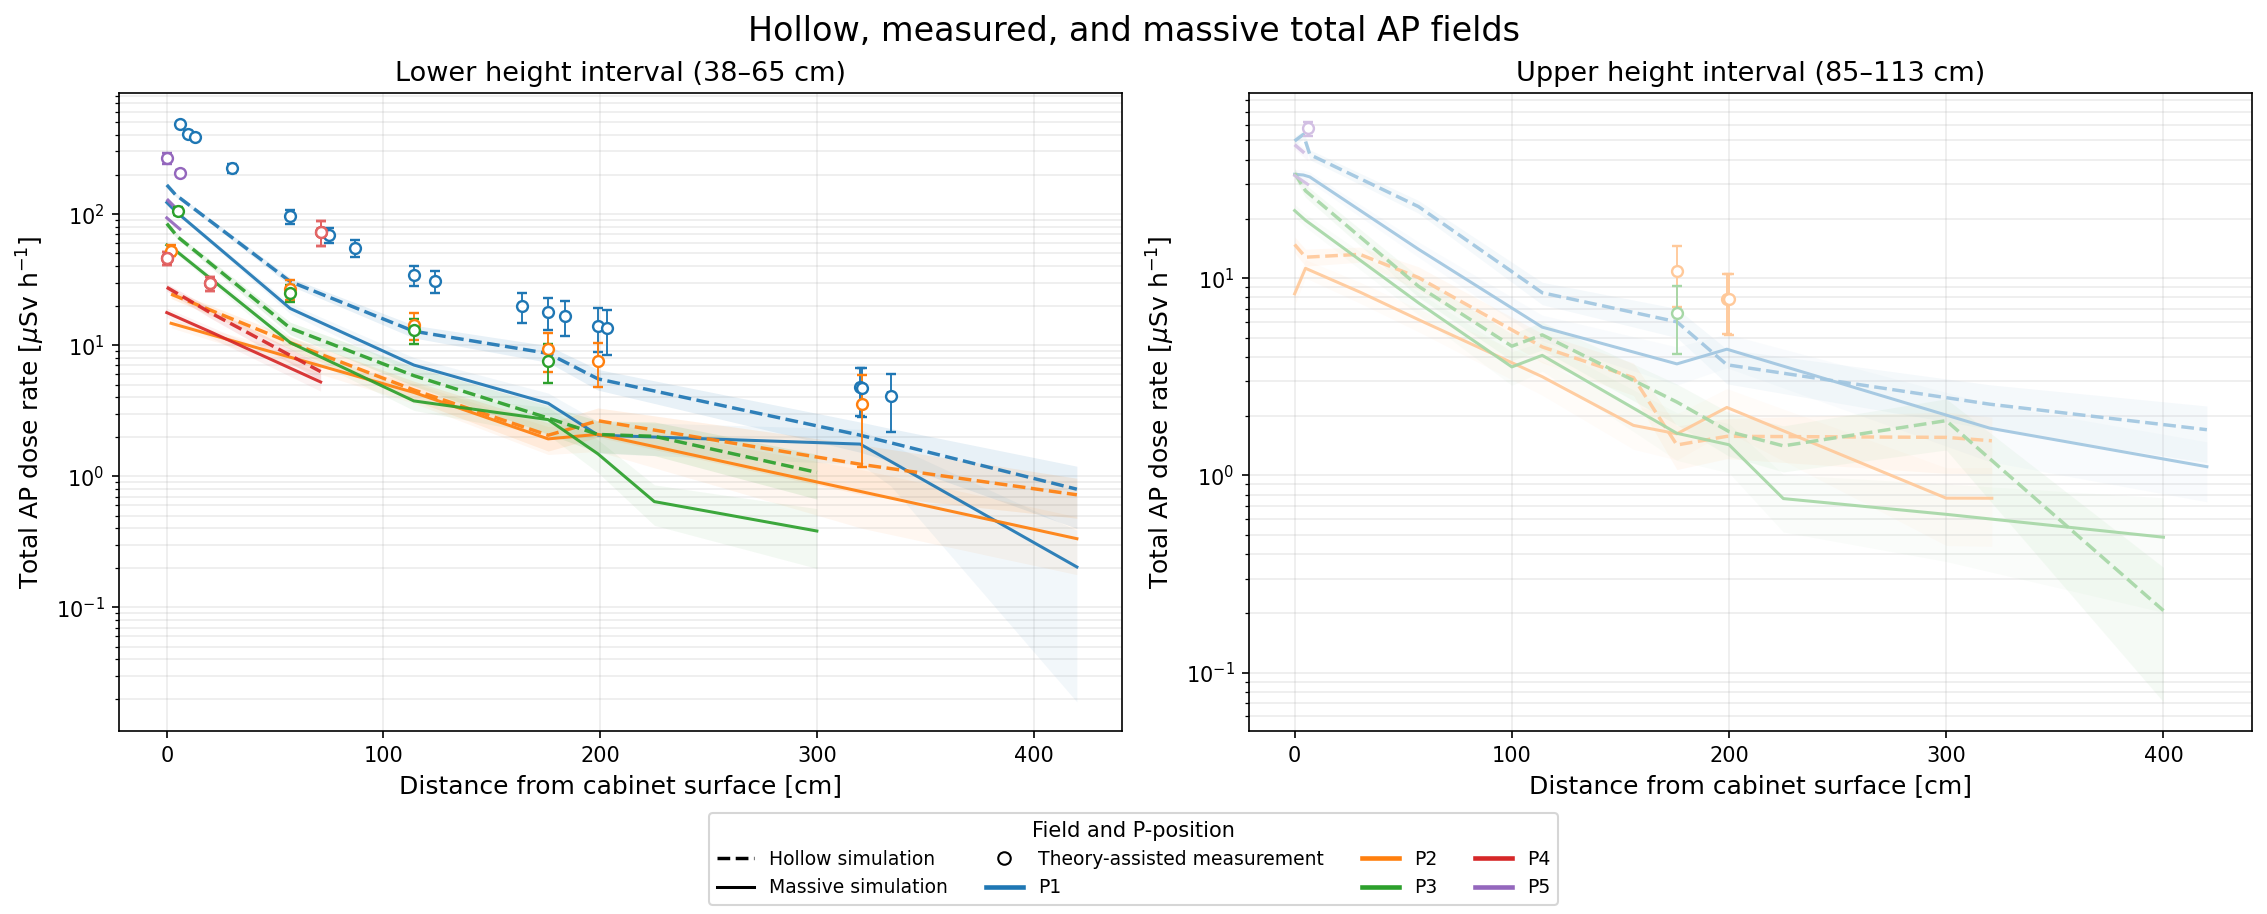

In [11]:
total_interval_figure, total_interval_axes = plt.subplots(
    1, 2, figsize=(15.0, 6.0), dpi=150, sharey=False, layout="constrained"
)

for axis, interval in zip(total_interval_axes, ["lower", "upper"]):
    interval_data = comparison_df.loc[
        comparison_df["analysis_height_interval"].eq(interval)
    ]
    for (position, height_cm), curve in interval_data.groupby(
        ["position", "height_cm"], sort=True
    ):
        curve = curve.sort_values("distance_cm")
        color = position_height_colors[(position, float(height_cm))]
        for model in ["hollow", "massive"]:
            available = curve[f"{model}_simulation_available"]
            simulation_curve = curve.loc[available]
            if not simulation_curve.empty:
                plot_simulation_curve(
                    axis,
                    simulation_curve["distance_cm"],
                    simulation_curve[f"{model}_total_ap_uSv_h"],
                    simulation_curve[f"u_mc_{model}_total_ap_uSv_h"],
                    color=color,
                    model=model,
                )
        measured_curve = curve.loc[
            curve["total_estimate_available"]
            & np.isfinite(curve["measured_total_ap_estimate_uSv_h"])
        ]
        if not measured_curve.empty:
            xerr = float(
                measured_curve["horizontal_position_limit_cm"].dropna().median()
            )
            plot_measured_points(
                axis,
                measured_curve["distance_cm"],
                measured_curve["measured_total_ap_estimate_uSv_h"],
                measured_curve["u_measured_total_ap_estimate_uSv_h"],
                color=color,
                marker="o",
                xerr=xerr,
            )

    axis.set_yscale("log")
    axis.set_xlabel("Distance from cabinet surface [cm]")
    axis.set_ylabel(r"Total AP dose rate [$\mu$Sv h$^{-1}$]")
    axis.set_title(ANALYSIS_HEIGHT_INTERVAL_LABELS[interval])
    axis.grid(True, which="both", alpha=0.24)
    axis.set_axisbelow(True)

position_handles = [
    Line2D([0], [0], color=POSITION_COLORS[p], linewidth=2.2, label=p)
    for p in POSITION_SEQUENCE
]
total_interval_figure.legend(
    handles=model_legend_handles() + position_handles,
    loc="outside lower center",
    ncol=4,
    title="Field and P-position",
)
total_interval_figure.suptitle(
    "Hollow, measured, and massive total AP fields",
    fontsize=16,
)
show_save_close(total_interval_figure, "total_ap_three_way_by_height_interval")


# 6) Position-wise total-field comparison

The P1–P5 panels make directional differences visible without crowding all
positions into one axis. Lighter shades correspond to higher exact target
heights within each position.


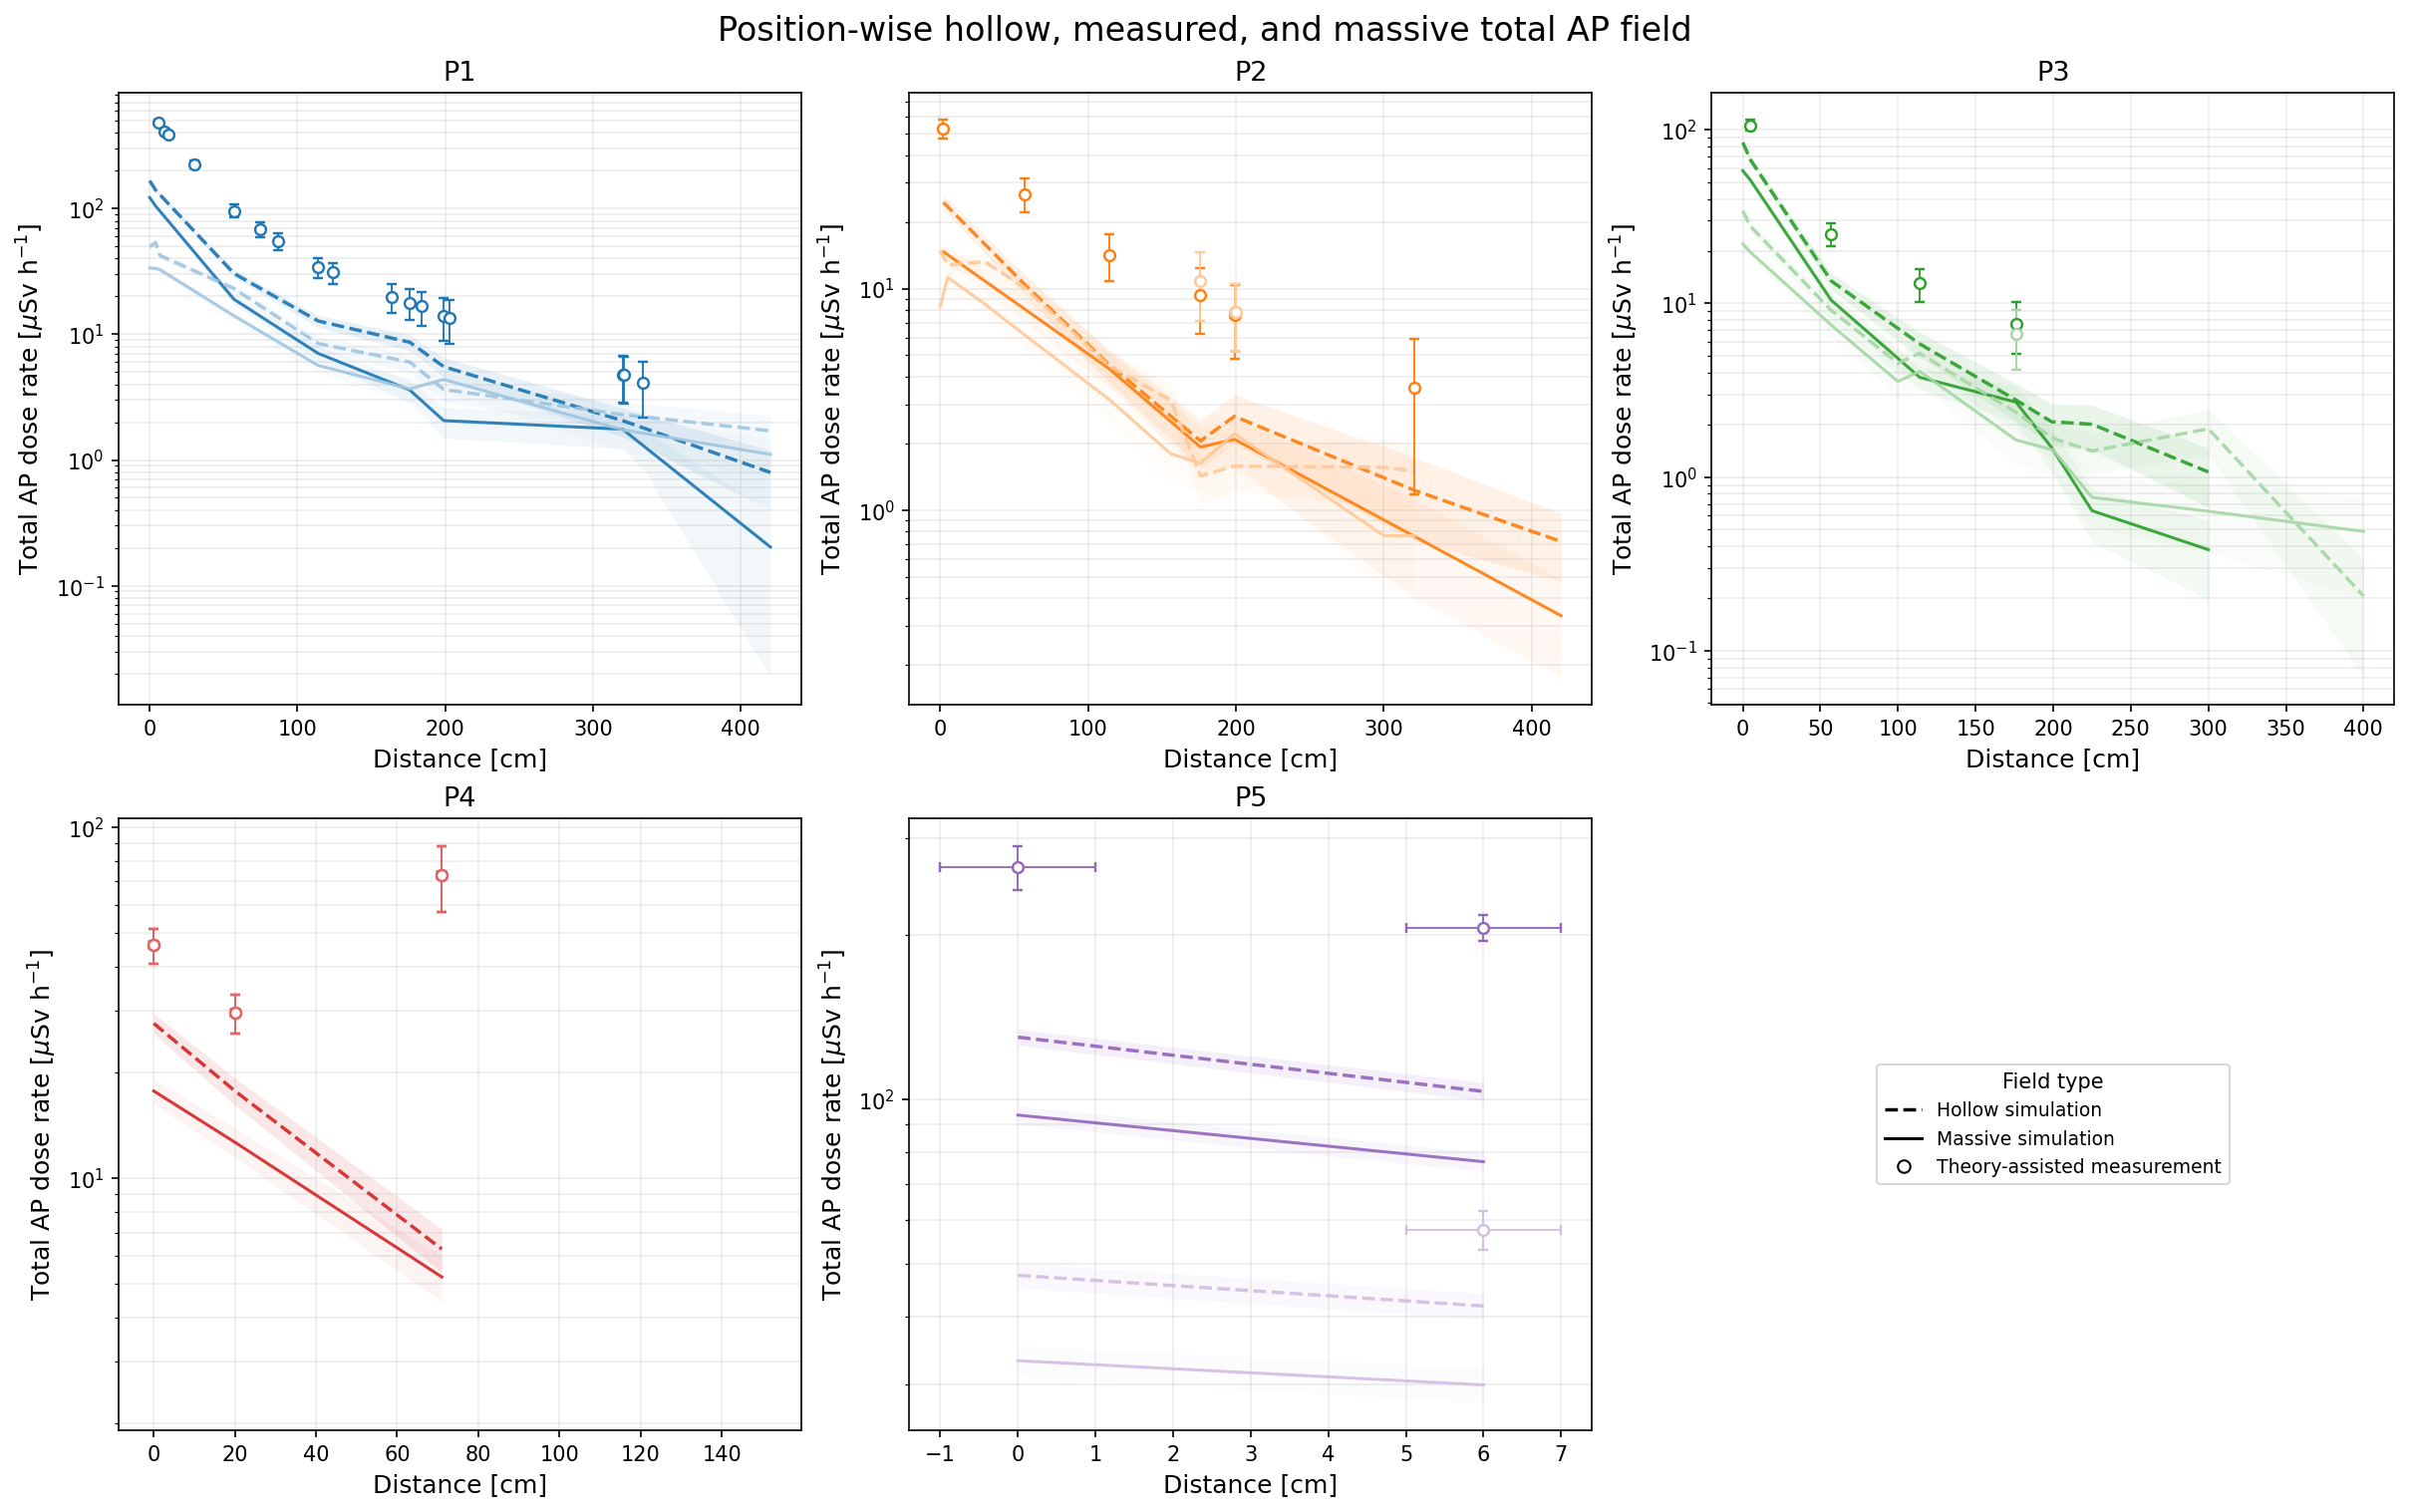

In [12]:
position_figure, position_axes = plt.subplots(
    2, 3, figsize=(16.0, 10.0), dpi=150, layout="constrained"
)
position_axes = position_axes.flatten()

for axis_index, position in enumerate(POSITION_SEQUENCE):
    axis = position_axes[axis_index]
    position_data = comparison_df.loc[comparison_df["position"].eq(position)]
    for height_cm, curve in position_data.groupby("height_cm", sort=True):
        curve = curve.sort_values("distance_cm")
        color = position_height_colors[(position, float(height_cm))]
        for model in ["hollow", "massive"]:
            simulation_curve = curve.loc[curve[f"{model}_simulation_available"]]
            if not simulation_curve.empty:
                plot_simulation_curve(
                    axis,
                    simulation_curve["distance_cm"],
                    simulation_curve[f"{model}_total_ap_uSv_h"],
                    simulation_curve[f"u_mc_{model}_total_ap_uSv_h"],
                    color=color,
                    model=model,
                )
        measured_curve = curve.loc[curve["total_estimate_available"]]
        if not measured_curve.empty:
            plot_measured_points(
                axis,
                measured_curve["distance_cm"],
                measured_curve["measured_total_ap_estimate_uSv_h"],
                measured_curve["u_measured_total_ap_estimate_uSv_h"],
                color=color,
                marker="o",
                xerr=float(
                    measured_curve["horizontal_position_limit_cm"].dropna().median()
                ),
            )
    axis.set_yscale("log")
    axis.set_title(position)
    axis.set_xlabel("Distance [cm]")
    axis.set_ylabel(r"Total AP dose rate [$\mu$Sv h$^{-1}$]")
    axis.grid(True, which="both", alpha=0.24)

position_axes[-1].axis("off")
height_handles = []
for height_cm in sorted(comparison_df["height_cm"].unique()):
    height_handles.append(
        Line2D([0], [0], color="0.45", linewidth=1.5, label=f"h={height_cm:g} cm")
    )
position_axes[-1].legend(
    handles=model_legend_handles(),
    loc="center",
    title="Field type",
)
position_figure.suptitle(
    "Position-wise hollow, measured, and massive total AP field",
    fontsize=16,
)
show_save_close(position_figure, "total_ap_three_way_by_position")


# 7) Neutron, gamma, and total components

Component plots prevent agreement in the total field from hiding compensating
neutron and gamma deviations. Rows show the lower and upper target-height
intervals; columns show neutron, gamma, and total AP dose rate.


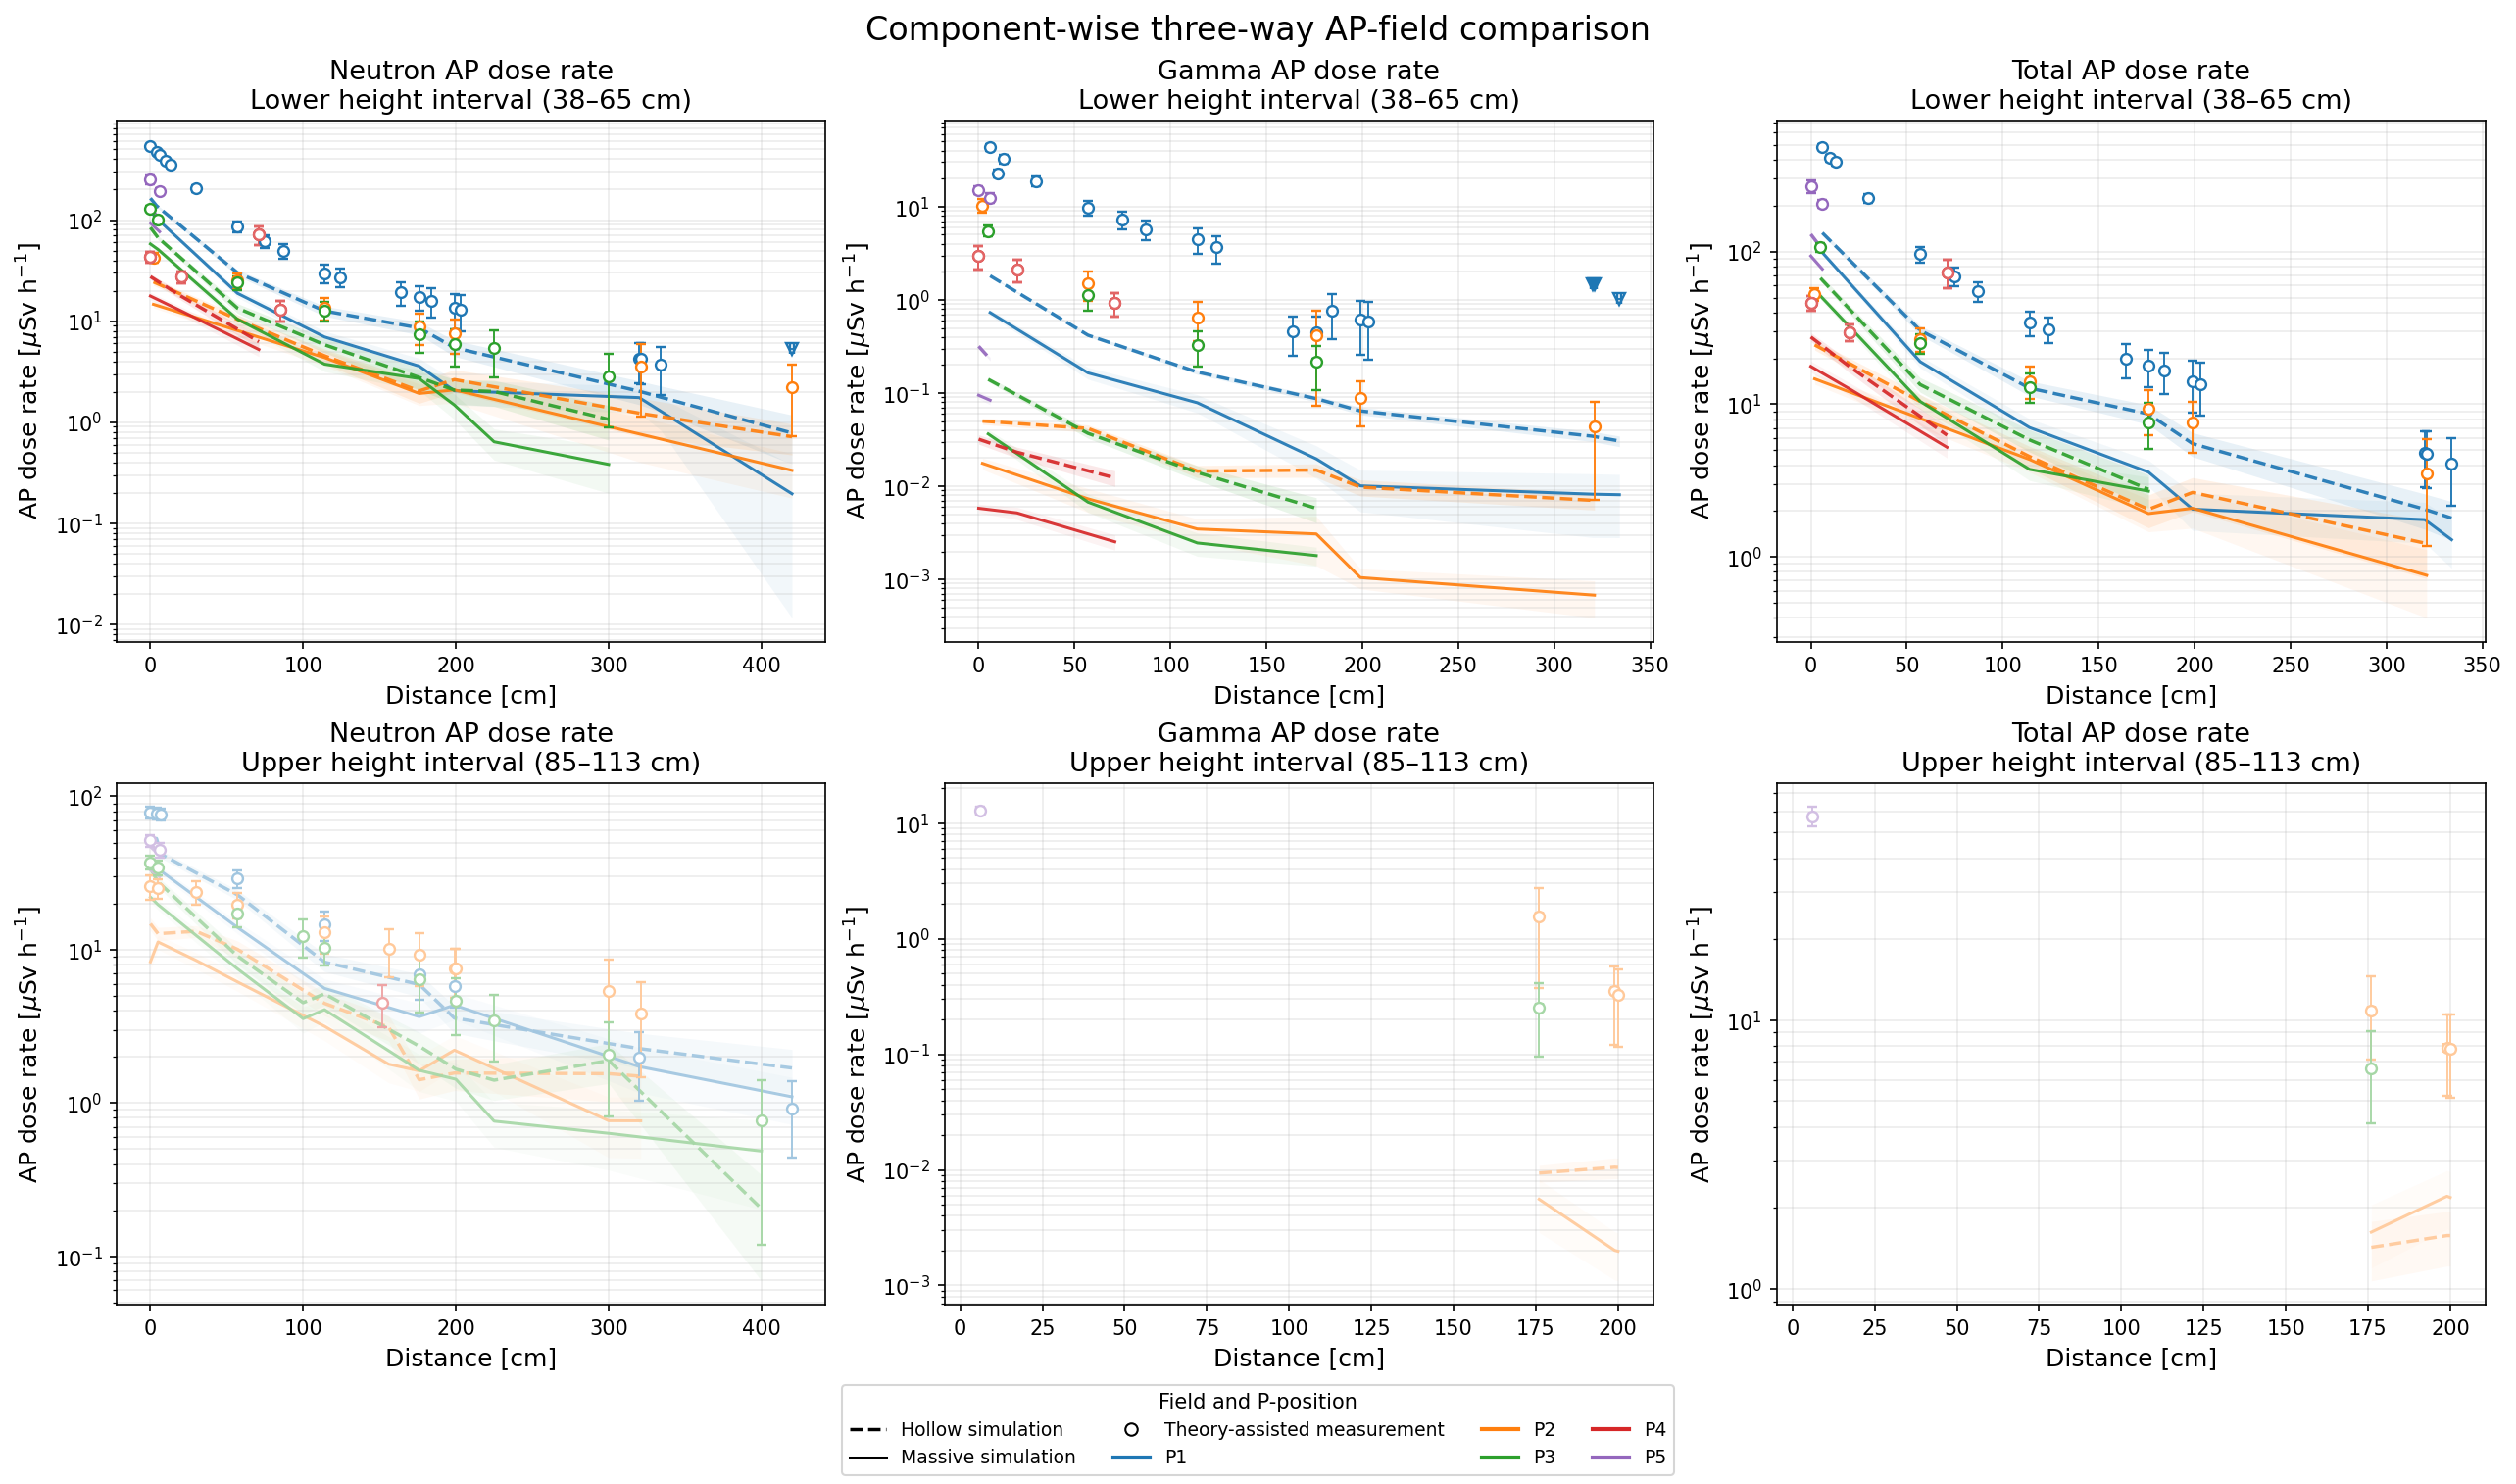

In [13]:
component_figure, component_axes = plt.subplots(
    2, 3, figsize=(17.0, 10.0), dpi=150, layout="constrained"
)

for row_index, interval in enumerate(["lower", "upper"]):
    interval_data = comparison_df.loc[
        comparison_df["analysis_height_interval"].eq(interval)
    ]
    for column_index, component in enumerate(["neutron", "gamma", "total"]):
        axis = component_axes[row_index, column_index]
        measured_column = COMPONENT_MEASURED_COLUMNS[component]
        measured_u_column = COMPONENT_MEASURED_U_COLUMNS[component]
        measured_available_column = COMPONENT_MEASURED_AVAILABLE_COLUMNS[component]
        for (position, height_cm), curve in interval_data.groupby(
            ["position", "height_cm"], sort=True
        ):
            curve = curve.sort_values("distance_cm")
            color = position_height_colors[(position, float(height_cm))]
            for model in ["hollow", "massive"]:
                simulation_curve = curve.loc[
                    curve[f"{model}_{component}_comparison_available"]
                ]
                if not simulation_curve.empty:
                    plot_simulation_curve(
                        axis,
                        simulation_curve["distance_cm"],
                        simulation_curve[f"{model}_{component}_ap_uSv_h"],
                        simulation_curve[f"u_mc_{model}_{component}_ap_uSv_h"],
                        color=color,
                        model=model,
                    )
            measured_curve = curve.loc[curve[measured_available_column]]
            if not measured_curve.empty:
                plot_measured_points(
                    axis,
                    measured_curve["distance_cm"],
                    measured_curve[measured_column],
                    measured_curve[measured_u_column],
                    color=color,
                    marker="o",
                    xerr=float(
                        measured_curve["horizontal_position_limit_cm"].dropna().median()
                    ),
                )
        axis.set_yscale("log")
        axis.set_xlabel("Distance [cm]")
        axis.set_ylabel(r"AP dose rate [$\mu$Sv h$^{-1}$]")
        axis.set_title(
            f"{COMPONENT_LABELS[component]}\n"
            f"{ANALYSIS_HEIGHT_INTERVAL_LABELS[interval]}"
        )
        axis.grid(True, which="both", alpha=0.23)

component_figure.legend(
    handles=model_legend_handles() + [
        Line2D([0], [0], color=POSITION_COLORS[p], linewidth=2.0, label=p)
        for p in POSITION_SEQUENCE
    ],
    loc="outside lower center",
    ncol=4,
    title="Field and P-position",
)
component_figure.suptitle(
    "Component-wise three-way AP-field comparison",
    fontsize=16,
)
show_save_close(component_figure, "component_ap_three_way_by_height_interval")


# 8) Total ratios on the common grid

$R=1$ denotes equality. Hollow-to-measured and massive-to-measured curves are
central-value diagnostics only. Hollow-to-massive points include MC-only
standard error bars under the independent-run assumption.


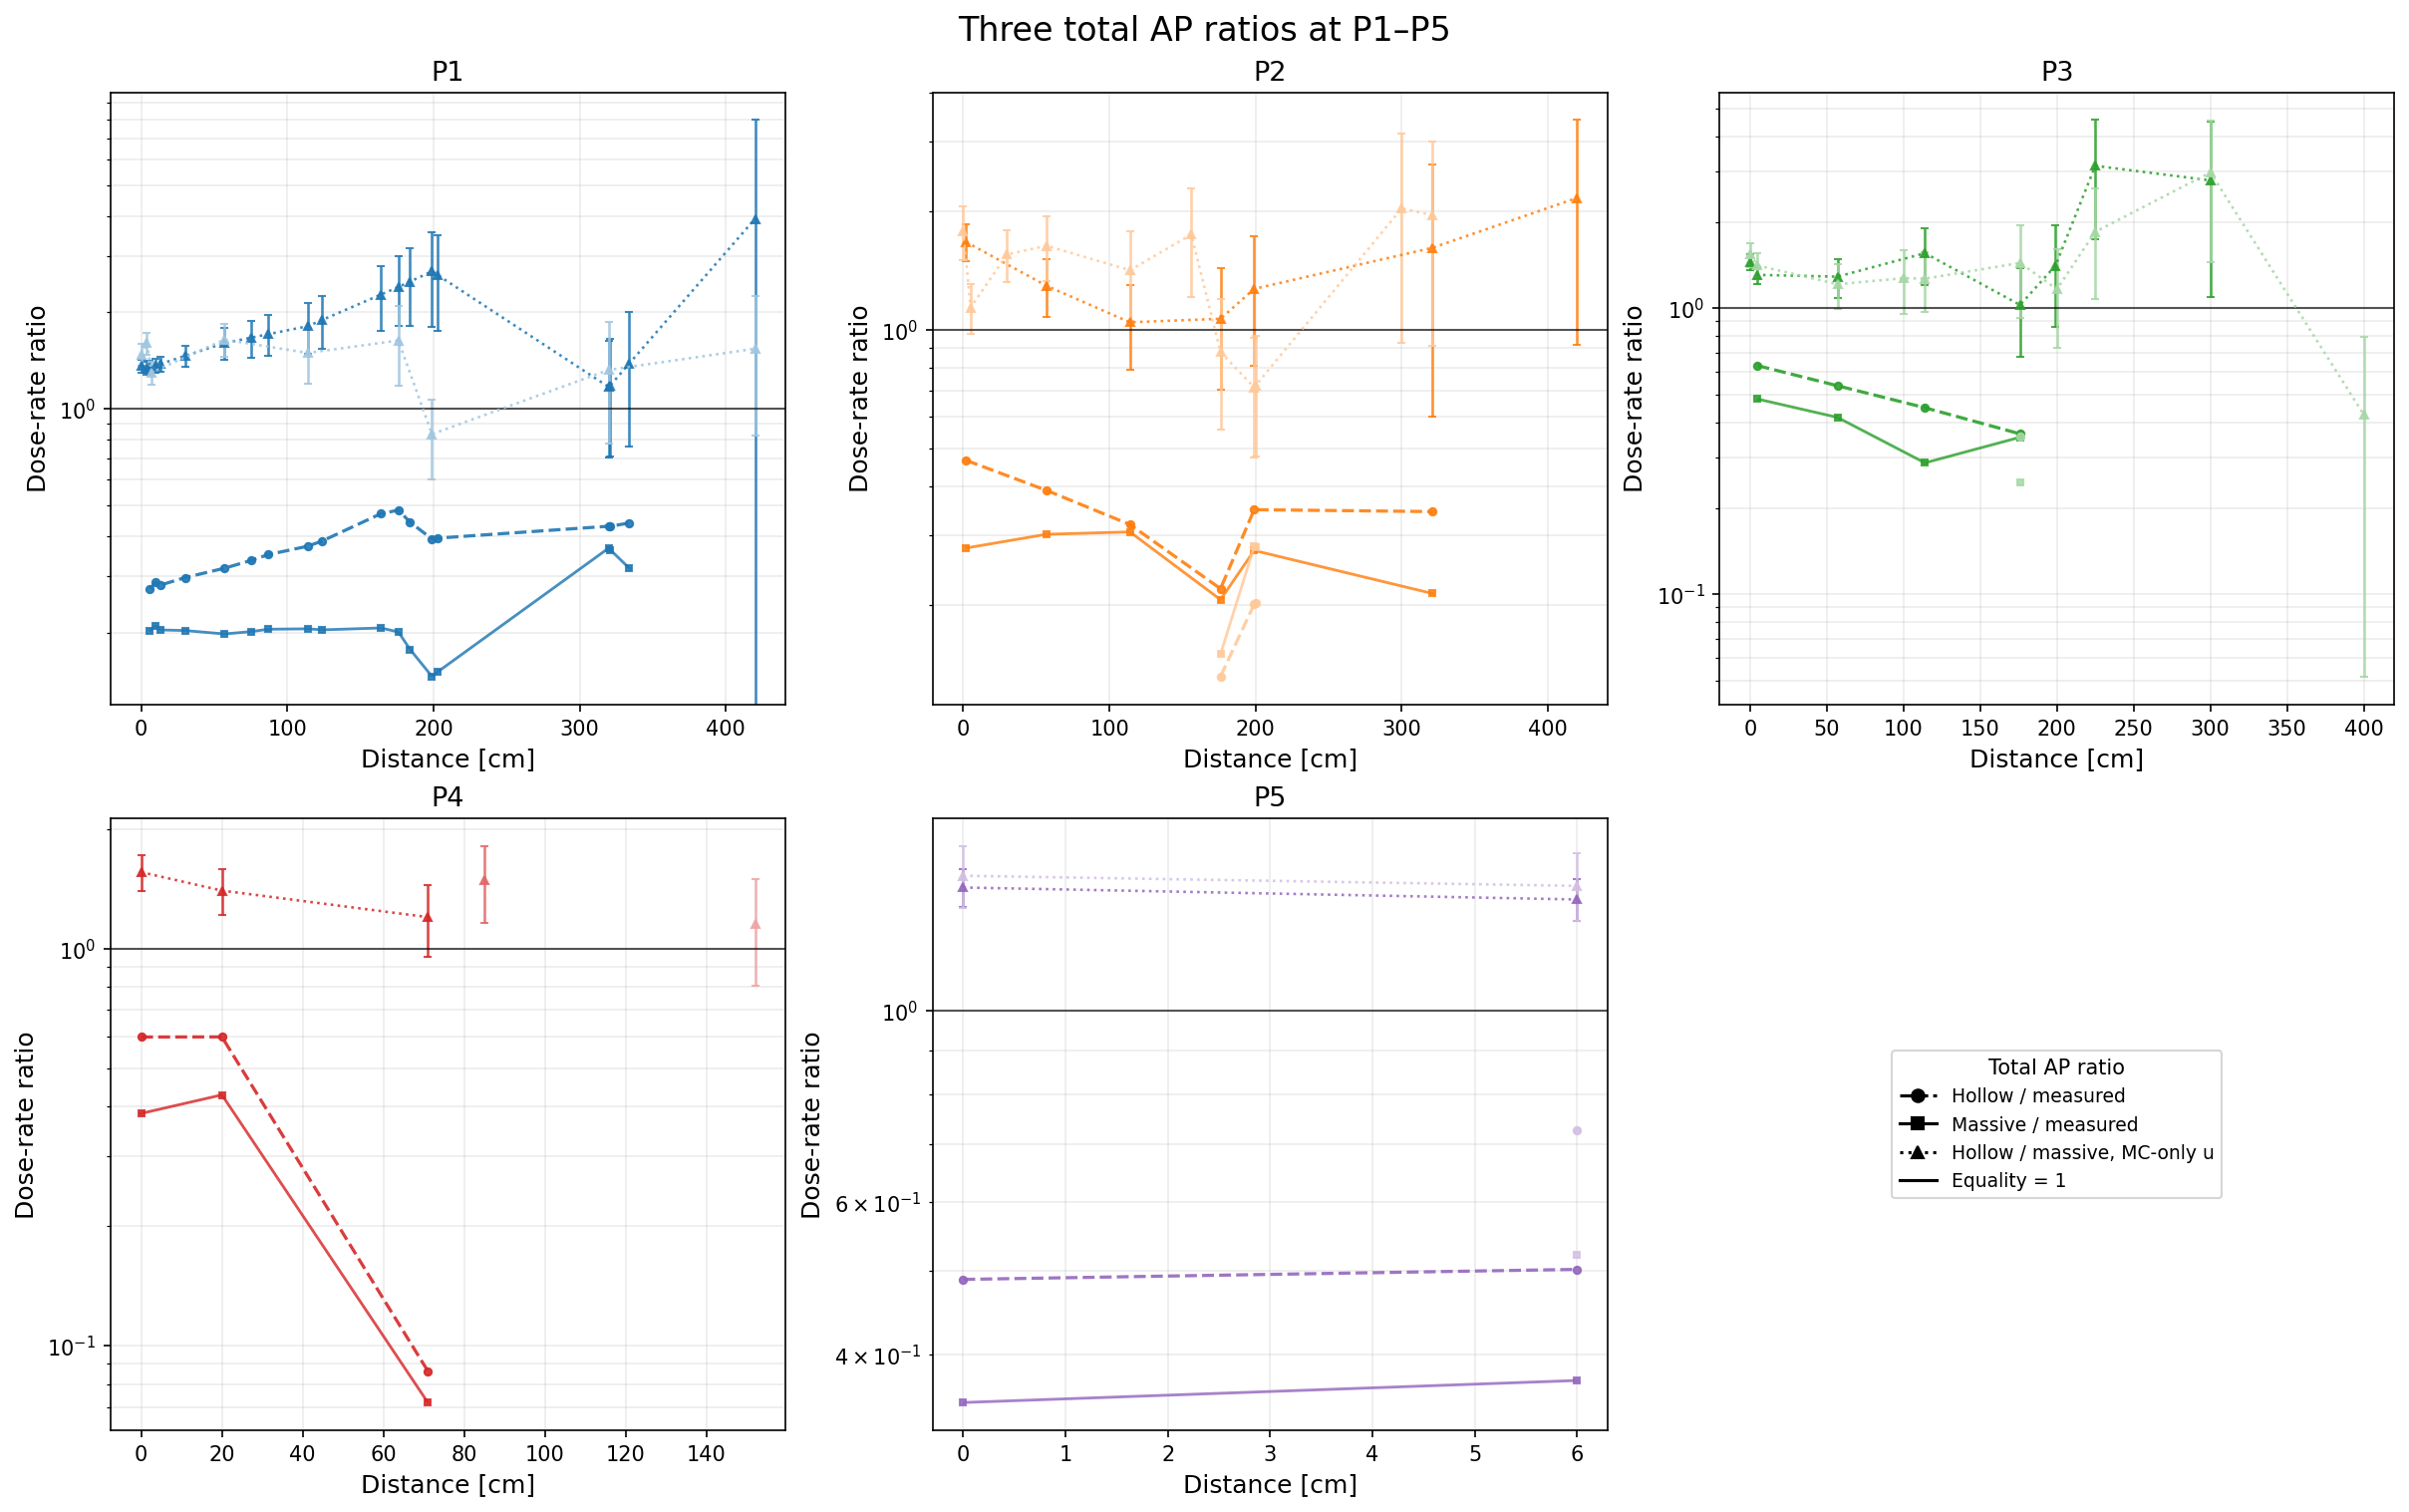

,comparison,component,compared_points,median_of_position_medians
0,hollow_to_massive,gamma,74,4.207213
1,hollow_to_massive,neutron,74,1.406120
2,hollow_to_massive,total,74,1.409439
3,hollow_to_measured,gamma,37,0.030086
4,hollow_to_measured,neutron,74,0.473390
5,hollow_to_measured,total,37,0.449213
6,massive_to_measured,gamma,37,0.006301
7,massive_to_measured,neutron,74,0.335700
8,massive_to_measured,total,37,0.354163


In [14]:
ratio_figure, ratio_axes = plt.subplots(
    2, 3, figsize=(16.0, 10.0), dpi=150, layout="constrained"
)
ratio_axes = ratio_axes.flatten()

for axis_index, position in enumerate(POSITION_SEQUENCE):
    axis = ratio_axes[axis_index]
    position_data = comparison_df.loc[comparison_df["position"].eq(position)]
    for height_cm, curve in position_data.groupby("height_cm", sort=True):
        curve = curve.sort_values("distance_cm")
        color = position_height_colors[(position, float(height_cm))]
        axis.plot(
            curve["distance_cm"],
            curve["hollow_to_measured_total_ratio"],
            color=color,
            linestyle="--",
            linewidth=1.55,
            marker="o",
            markersize=3.5,
            alpha=0.90,
        )
        axis.plot(
            curve["distance_cm"],
            curve["massive_to_measured_total_ratio"],
            color=color,
            linestyle="-",
            linewidth=1.35,
            marker="s",
            markersize=3.2,
            alpha=0.82,
        )
        direct = curve.loc[curve["hollow_massive_total_comparison_available"]]
        if not direct.empty:
            axis.errorbar(
                direct["distance_cm"],
                direct["hollow_to_massive_total_ratio"],
                yerr=direct["u_mc_hollow_to_massive_total_ratio"],
                color=color,
                linestyle=":",
                linewidth=1.25,
                marker="^",
                markersize=3.5,
                capsize=2.0,
                alpha=0.86,
            )
    axis.axhline(1.0, color="black", linewidth=1.0, alpha=0.65)
    axis.set_yscale("log")
    axis.set_title(position)
    axis.set_xlabel("Distance [cm]")
    axis.set_ylabel("Dose-rate ratio")
    axis.grid(True, which="both", alpha=0.23)

ratio_axes[-1].axis("off")
ratio_axes[-1].legend(
    handles=[
        Line2D([0], [0], color="black", linestyle="--", marker="o", label="Hollow / measured"),
        Line2D([0], [0], color="black", linestyle="-", marker="s", label="Massive / measured"),
        Line2D([0], [0], color="black", linestyle=":", marker="^", label="Hollow / massive, MC-only u"),
        Line2D([0], [0], color="black", linestyle="-", label="Equality = 1"),
    ],
    loc="center",
    title="Total AP ratio",
)
ratio_figure.suptitle("Three total AP ratios at P1–P5", fontsize=16)
show_save_close(ratio_figure, "total_ap_three_ratios_by_position")


ratio_summary_rows = []
ratio_definitions = {
    "hollow_to_measured": "hollow_to_measured_{component}_ratio",
    "massive_to_measured": "massive_to_measured_{component}_ratio",
    "hollow_to_massive": "hollow_to_massive_{component}_ratio",
}
for comparison_name, template in ratio_definitions.items():
    for component in ["neutron", "gamma", "total"]:
        ratio_column = template.format(component=component)
        for position, group in comparison_df.groupby("position", sort=True):
            values = pd.to_numeric(group[ratio_column], errors="coerce")
            values = values[np.isfinite(values) & (values > 0.0)]
            ratio_summary_rows.append({
                "comparison": comparison_name,
                "component": component,
                "position": position,
                "number_of_points": len(values),
                "geometric_mean_ratio": (
                    float(np.exp(np.mean(np.log(values)))) if len(values) else np.nan
                ),
                "median_ratio": float(np.median(values)) if len(values) else np.nan,
                "minimum_ratio": float(np.min(values)) if len(values) else np.nan,
                "maximum_ratio": float(np.max(values)) if len(values) else np.nan,
                "fraction_between_0_5_and_2": (
                    float(np.mean((values >= 0.5) & (values <= 2.0)))
                    if len(values) else np.nan
                ),
            })

ratio_summary_df = pd.DataFrame(ratio_summary_rows)
display(
    ratio_summary_df.groupby(["comparison", "component"], as_index=False).agg(
        compared_points=("number_of_points", "sum"),
        median_of_position_medians=("median_ratio", "median"),
    )
)


# 9) Relative residuals and descriptive agreement gain

The relative total residual is

$$
r_{k/M}=100\%\,
\frac{\dot H_k-\widehat{\dot H}_{M}}
     {\widehat{\dot H}_{M}},
\qquad k\in\{H,S\}.
$$

The central agreement-gain statistic is

$$
G=|\log_{10}R_{S/M}|-|\log_{10}R_{H/M}|.
$$

$G>0$ means the hollow central value is closer to the measured estimate on a
multiplicative scale; $G<0$ means the massive result is closer. This is a
descriptive ranking, not a statistical significance test.


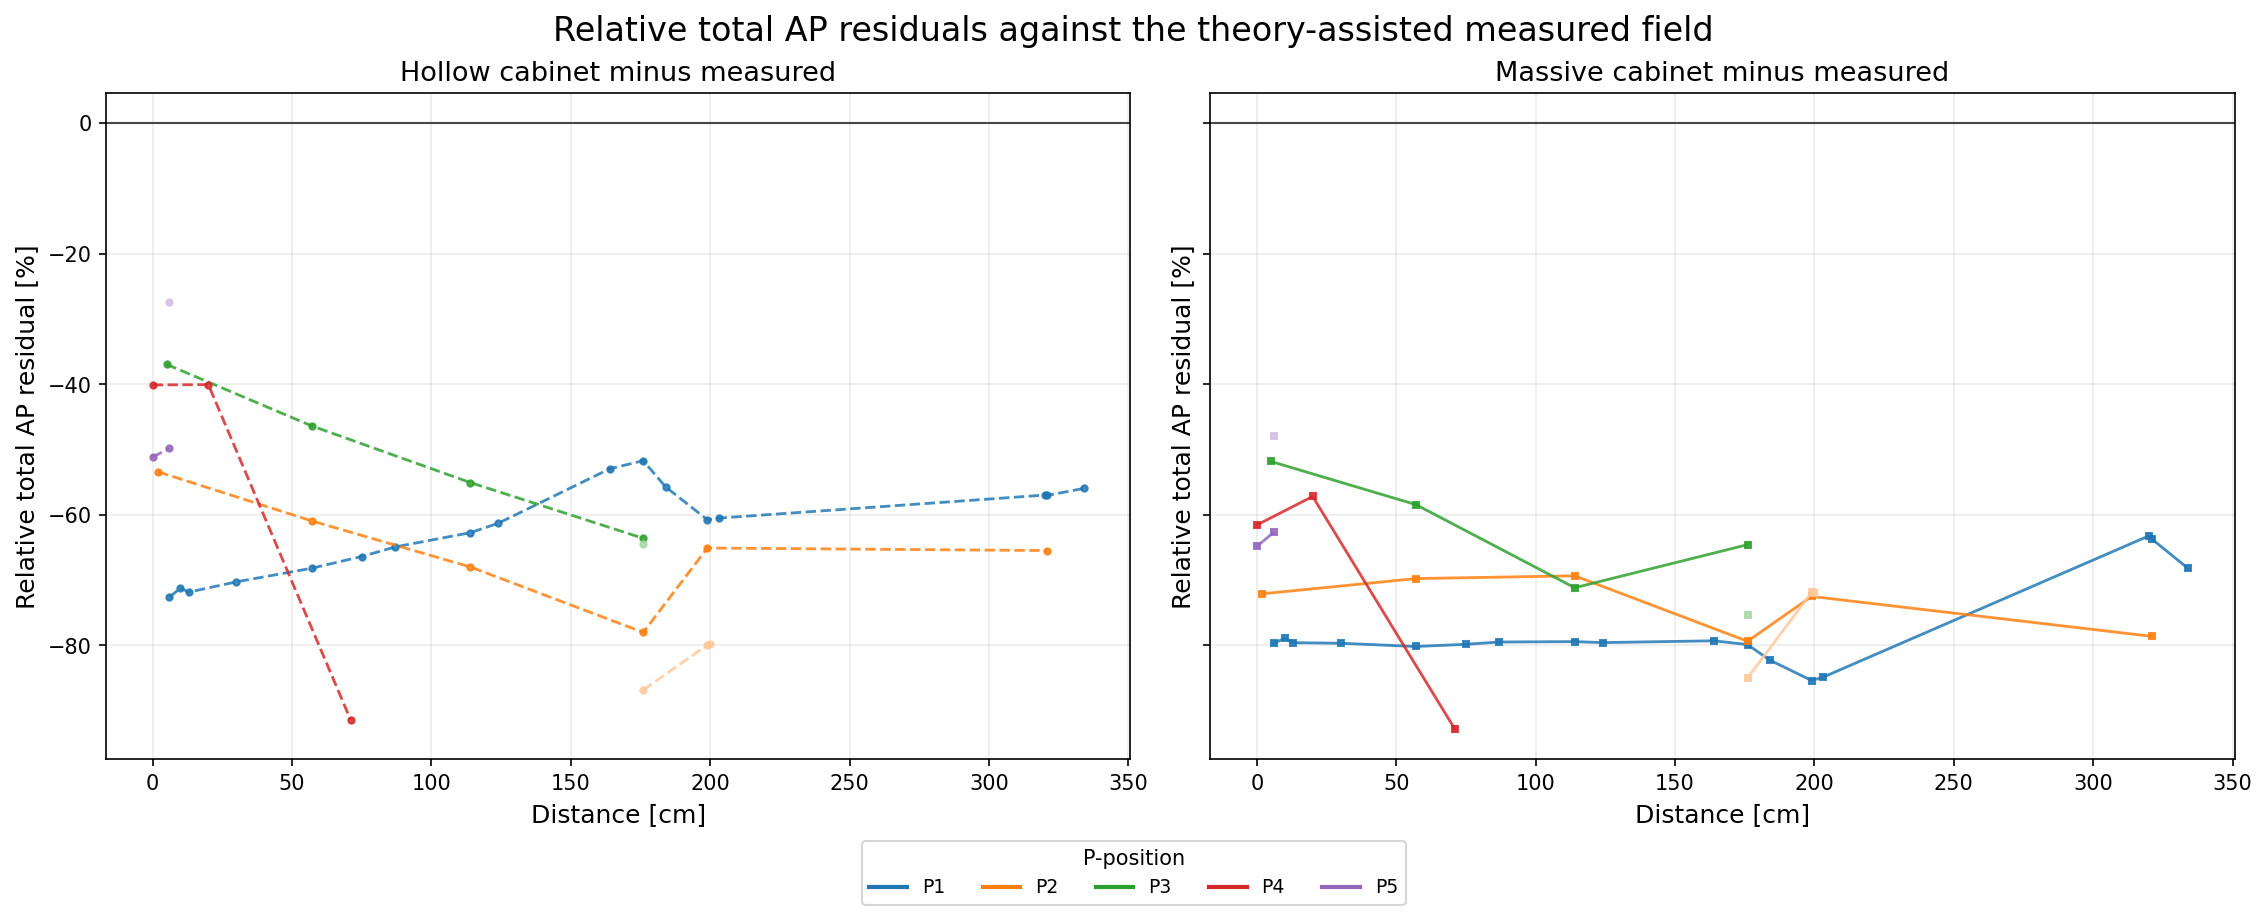

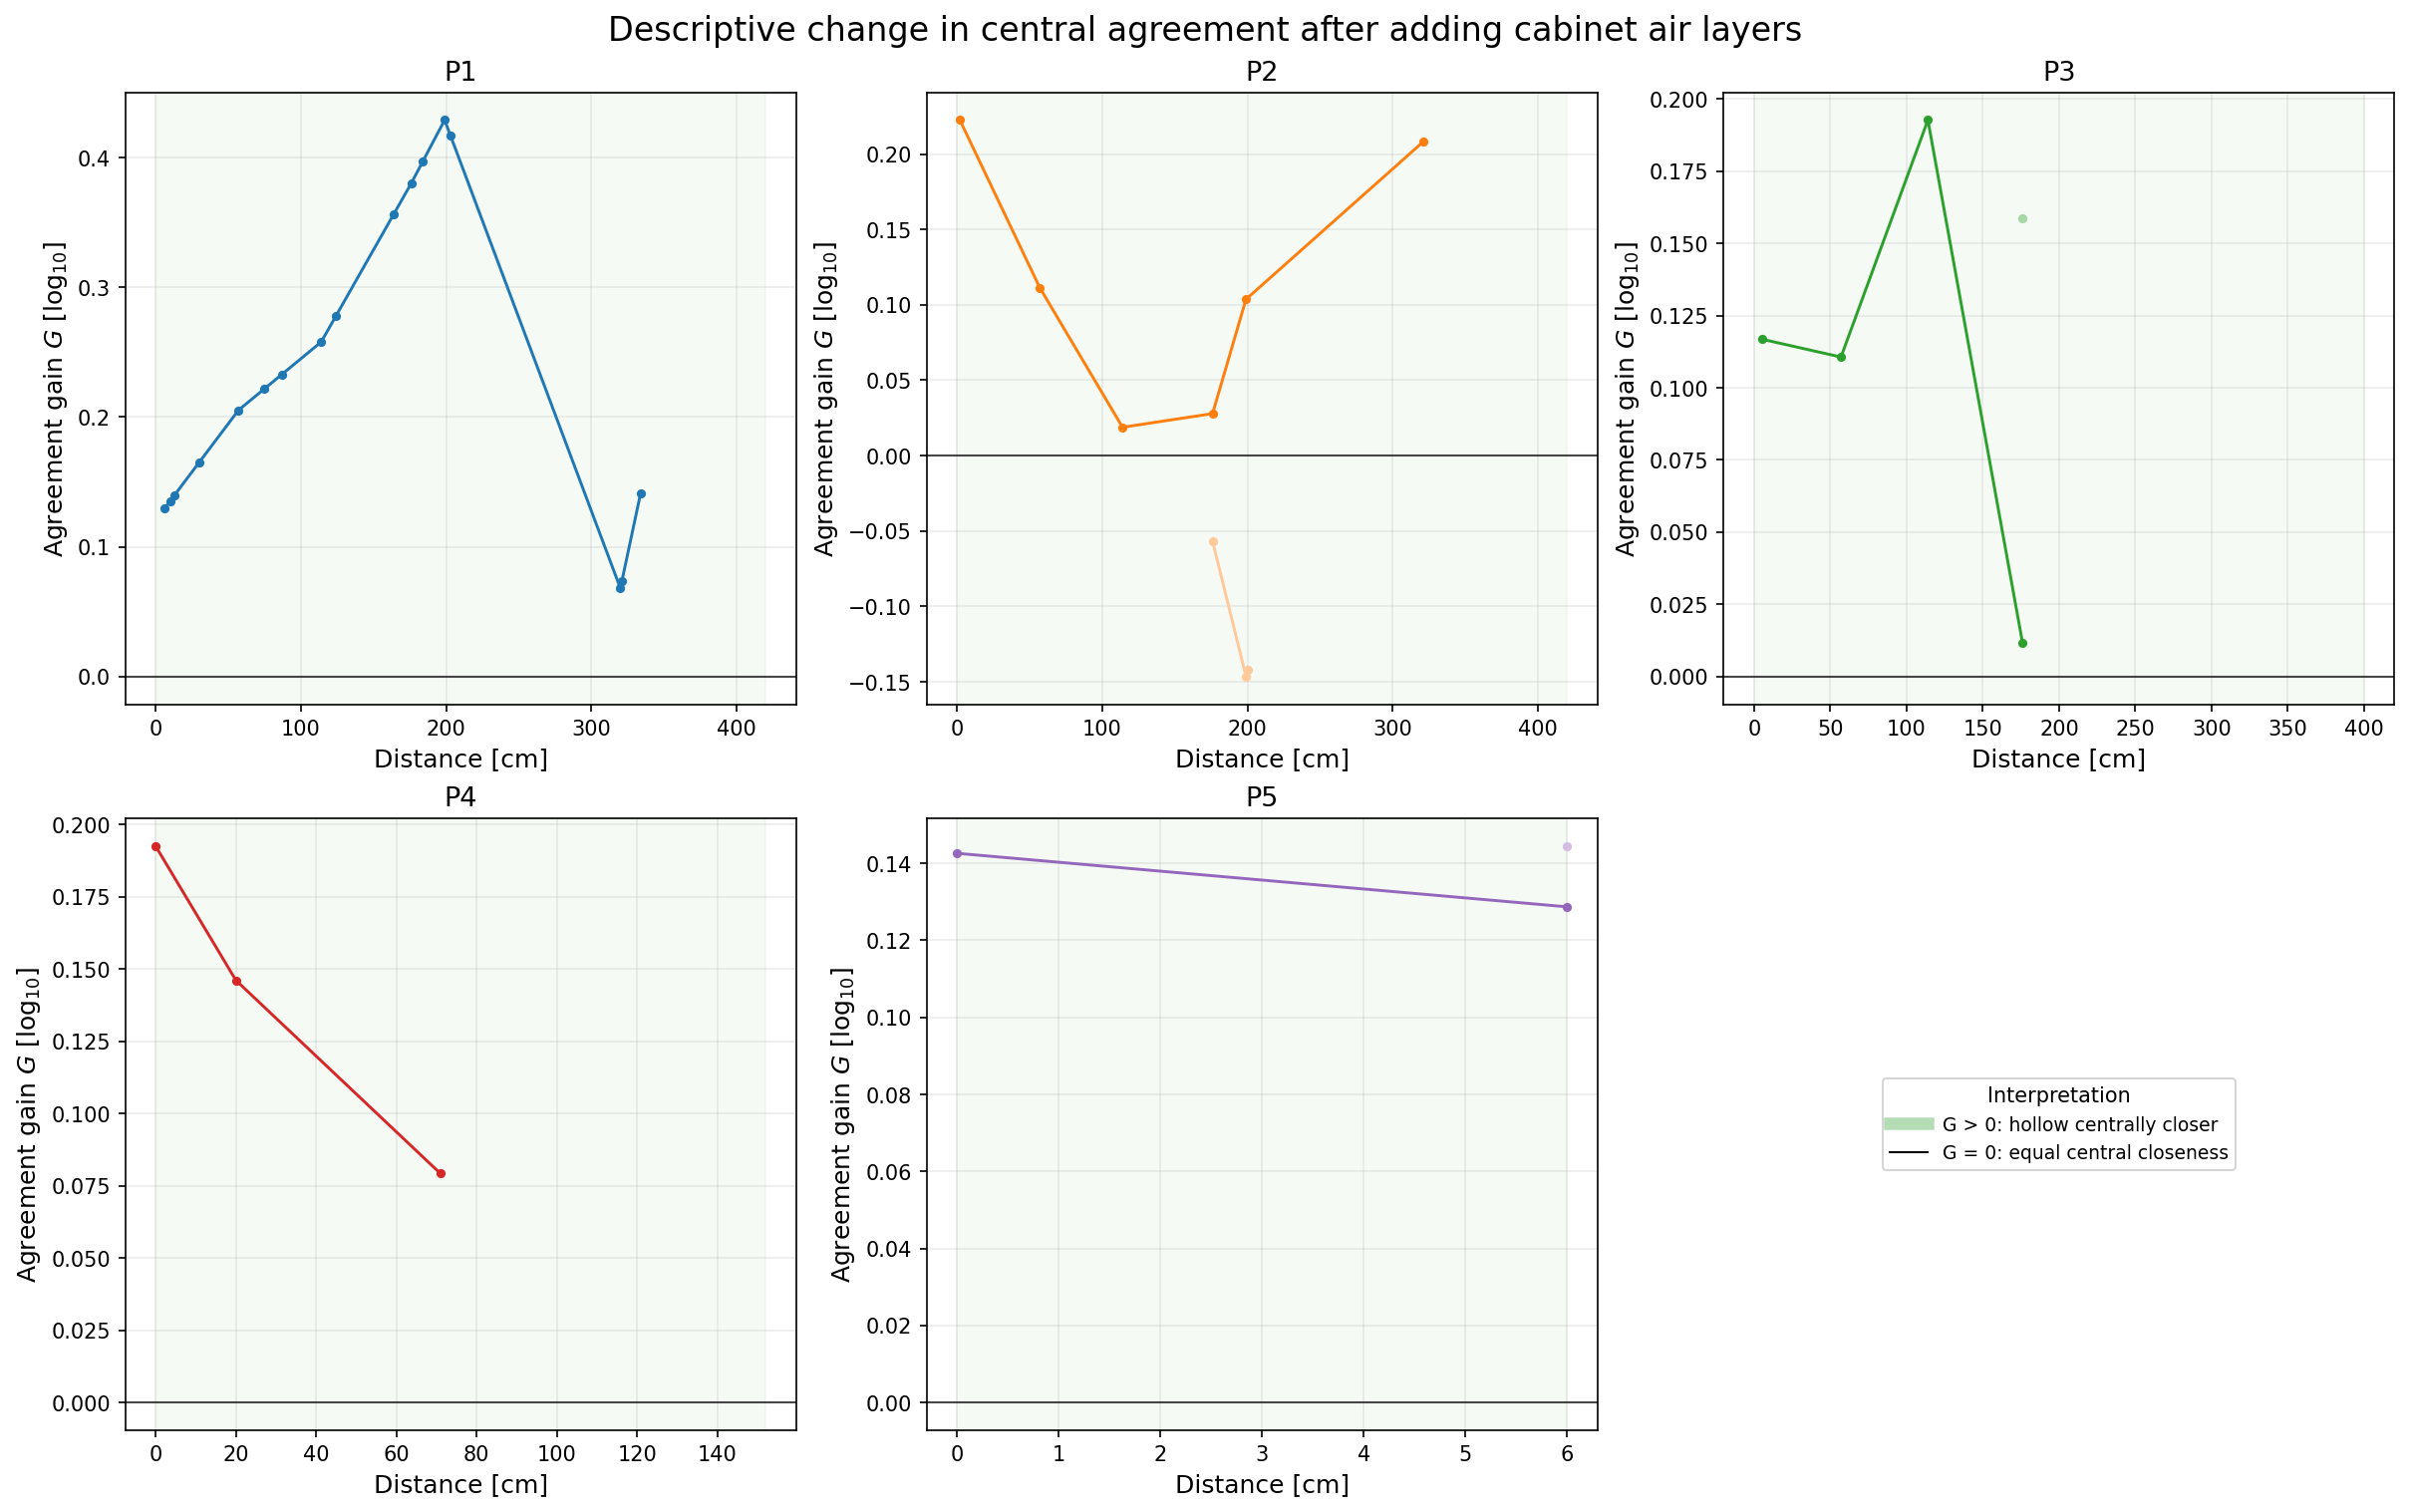

,component,position,number_of_comparisons,median_agreement_gain_log10,mean_agreement_gain_log10,fraction_hollow_centrally_closer
0,neutron,P1,29,0.171325,0.194558,0.931034
1,neutron,P2,18,0.170041,0.131047,0.833333
2,neutron,P3,18,0.148022,0.161083,0.944444
3,neutron,P4,5,0.145752,0.129842,1.000000
4,neutron,P5,4,0.142005,0.141441,1.000000
5,gamma,P1,17,0.404377,0.517343,1.000000
6,gamma,P2,9,0.719779,0.685965,1.000000
7,gamma,P3,5,0.630468,0.643635,1.000000
8,gamma,P4,3,0.685978,0.692829,1.000000
9,gamma,P5,3,0.525420,0.534935,1.000000


In [15]:
residual_figure, residual_axes = plt.subplots(
    1, 2, figsize=(15.0, 6.0), dpi=150, sharey=True, layout="constrained"
)
for axis, model in zip(residual_axes, ["hollow", "massive"]):
    for (position, height_cm), curve in comparison_df.groupby(
        ["position", "height_cm"], sort=True
    ):
        curve = curve.sort_values("distance_cm")
        color = position_height_colors[(position, float(height_cm))]
        axis.plot(
            curve["distance_cm"],
            curve[f"{model}_minus_measured_total_relative_residual_percent"],
            color=color,
            linestyle=MODEL_STYLES[model]["linestyle"],
            linewidth=1.35,
            marker="o" if model == "hollow" else "s",
            markersize=3.0,
            alpha=0.84,
        )
    axis.axhline(0.0, color="black", linewidth=1.0, alpha=0.70)
    axis.set_xlabel("Distance [cm]")
    axis.set_ylabel("Relative total AP residual [%]")
    axis.set_title(f"{MODEL_STYLES[model]['label']} minus measured")
    axis.grid(True, alpha=0.24)

residual_figure.legend(
    handles=[
        Line2D([0], [0], color=POSITION_COLORS[p], linewidth=2.0, label=p)
        for p in POSITION_SEQUENCE
    ],
    loc="outside lower center",
    ncol=5,
    title="P-position",
)
residual_figure.suptitle(
    "Relative total AP residuals against the theory-assisted measured field",
    fontsize=16,
)
show_save_close(residual_figure, "relative_total_ap_residual_hollow_and_massive")


gain_figure, gain_axes = plt.subplots(
    2, 3, figsize=(16.0, 10.0), dpi=150, layout="constrained"
)
gain_axes = gain_axes.flatten()
for axis_index, position in enumerate(POSITION_SEQUENCE):
    axis = gain_axes[axis_index]
    position_data = comparison_df.loc[comparison_df["position"].eq(position)]
    for height_cm, curve in position_data.groupby("height_cm", sort=True):
        curve = curve.sort_values("distance_cm")
        color = position_height_colors[(position, float(height_cm))]
        axis.plot(
            curve["distance_cm"],
            curve["hollow_central_agreement_gain_total_log10"],
            color=color,
            linewidth=1.4,
            marker="o",
            markersize=3.4,
            label=f"h={height_cm:g} cm",
        )
    axis.axhline(0.0, color="black", linewidth=1.0, alpha=0.70)
    axis.fill_between(
        [position_data["distance_cm"].min(), position_data["distance_cm"].max()],
        0.0,
        1.0,
        color="tab:green",
        alpha=0.045,
        transform=axis.get_xaxis_transform(),
    )
    axis.set_title(position)
    axis.set_xlabel("Distance [cm]")
    axis.set_ylabel(r"Agreement gain $G$ [log$_{10}$]")
    axis.grid(True, alpha=0.24)

gain_axes[-1].axis("off")
gain_axes[-1].legend(
    handles=[
        Line2D([0], [0], color="tab:green", linewidth=6, alpha=0.35, label="G > 0: hollow centrally closer"),
        Line2D([0], [0], color="black", linewidth=1.0, label="G = 0: equal central closeness"),
    ],
    loc="center",
    title="Interpretation",
)
gain_figure.suptitle(
    "Descriptive change in central agreement after adding cabinet air layers",
    fontsize=16,
)
show_save_close(gain_figure, "hollow_central_agreement_gain_by_position")


gain_summary_rows = []
for component in ["neutron", "gamma", "total"]:
    gain_column = f"hollow_central_agreement_gain_{component}_log10"
    closer_column = f"hollow_centrally_closer_to_measured_{component}"
    for position, group in comparison_df.groupby("position", sort=True):
        valid = group[gain_column].notna()
        gains = group.loc[valid, gain_column].astype(float)
        closer = group.loc[valid, closer_column].astype("boolean")
        gain_summary_rows.append({
            "component": component,
            "position": position,
            "number_of_comparisons": int(valid.sum()),
            "median_agreement_gain_log10": (
                float(gains.median()) if len(gains) else np.nan
            ),
            "mean_agreement_gain_log10": (
                float(gains.mean()) if len(gains) else np.nan
            ),
            "fraction_hollow_centrally_closer": (
                float(closer.mean()) if len(closer) else np.nan
            ),
        })

agreement_gain_summary_df = pd.DataFrame(gain_summary_rows)
display(agreement_gain_summary_df)


# 10) One-to-one component and total comparison

Measured estimates are placed on the horizontal axis and simulation values on
the vertical axis. The diagonal denotes equality. Horizontal and vertical
uncertainties are displayed separately and are not combined into an
independence-assuming residual.


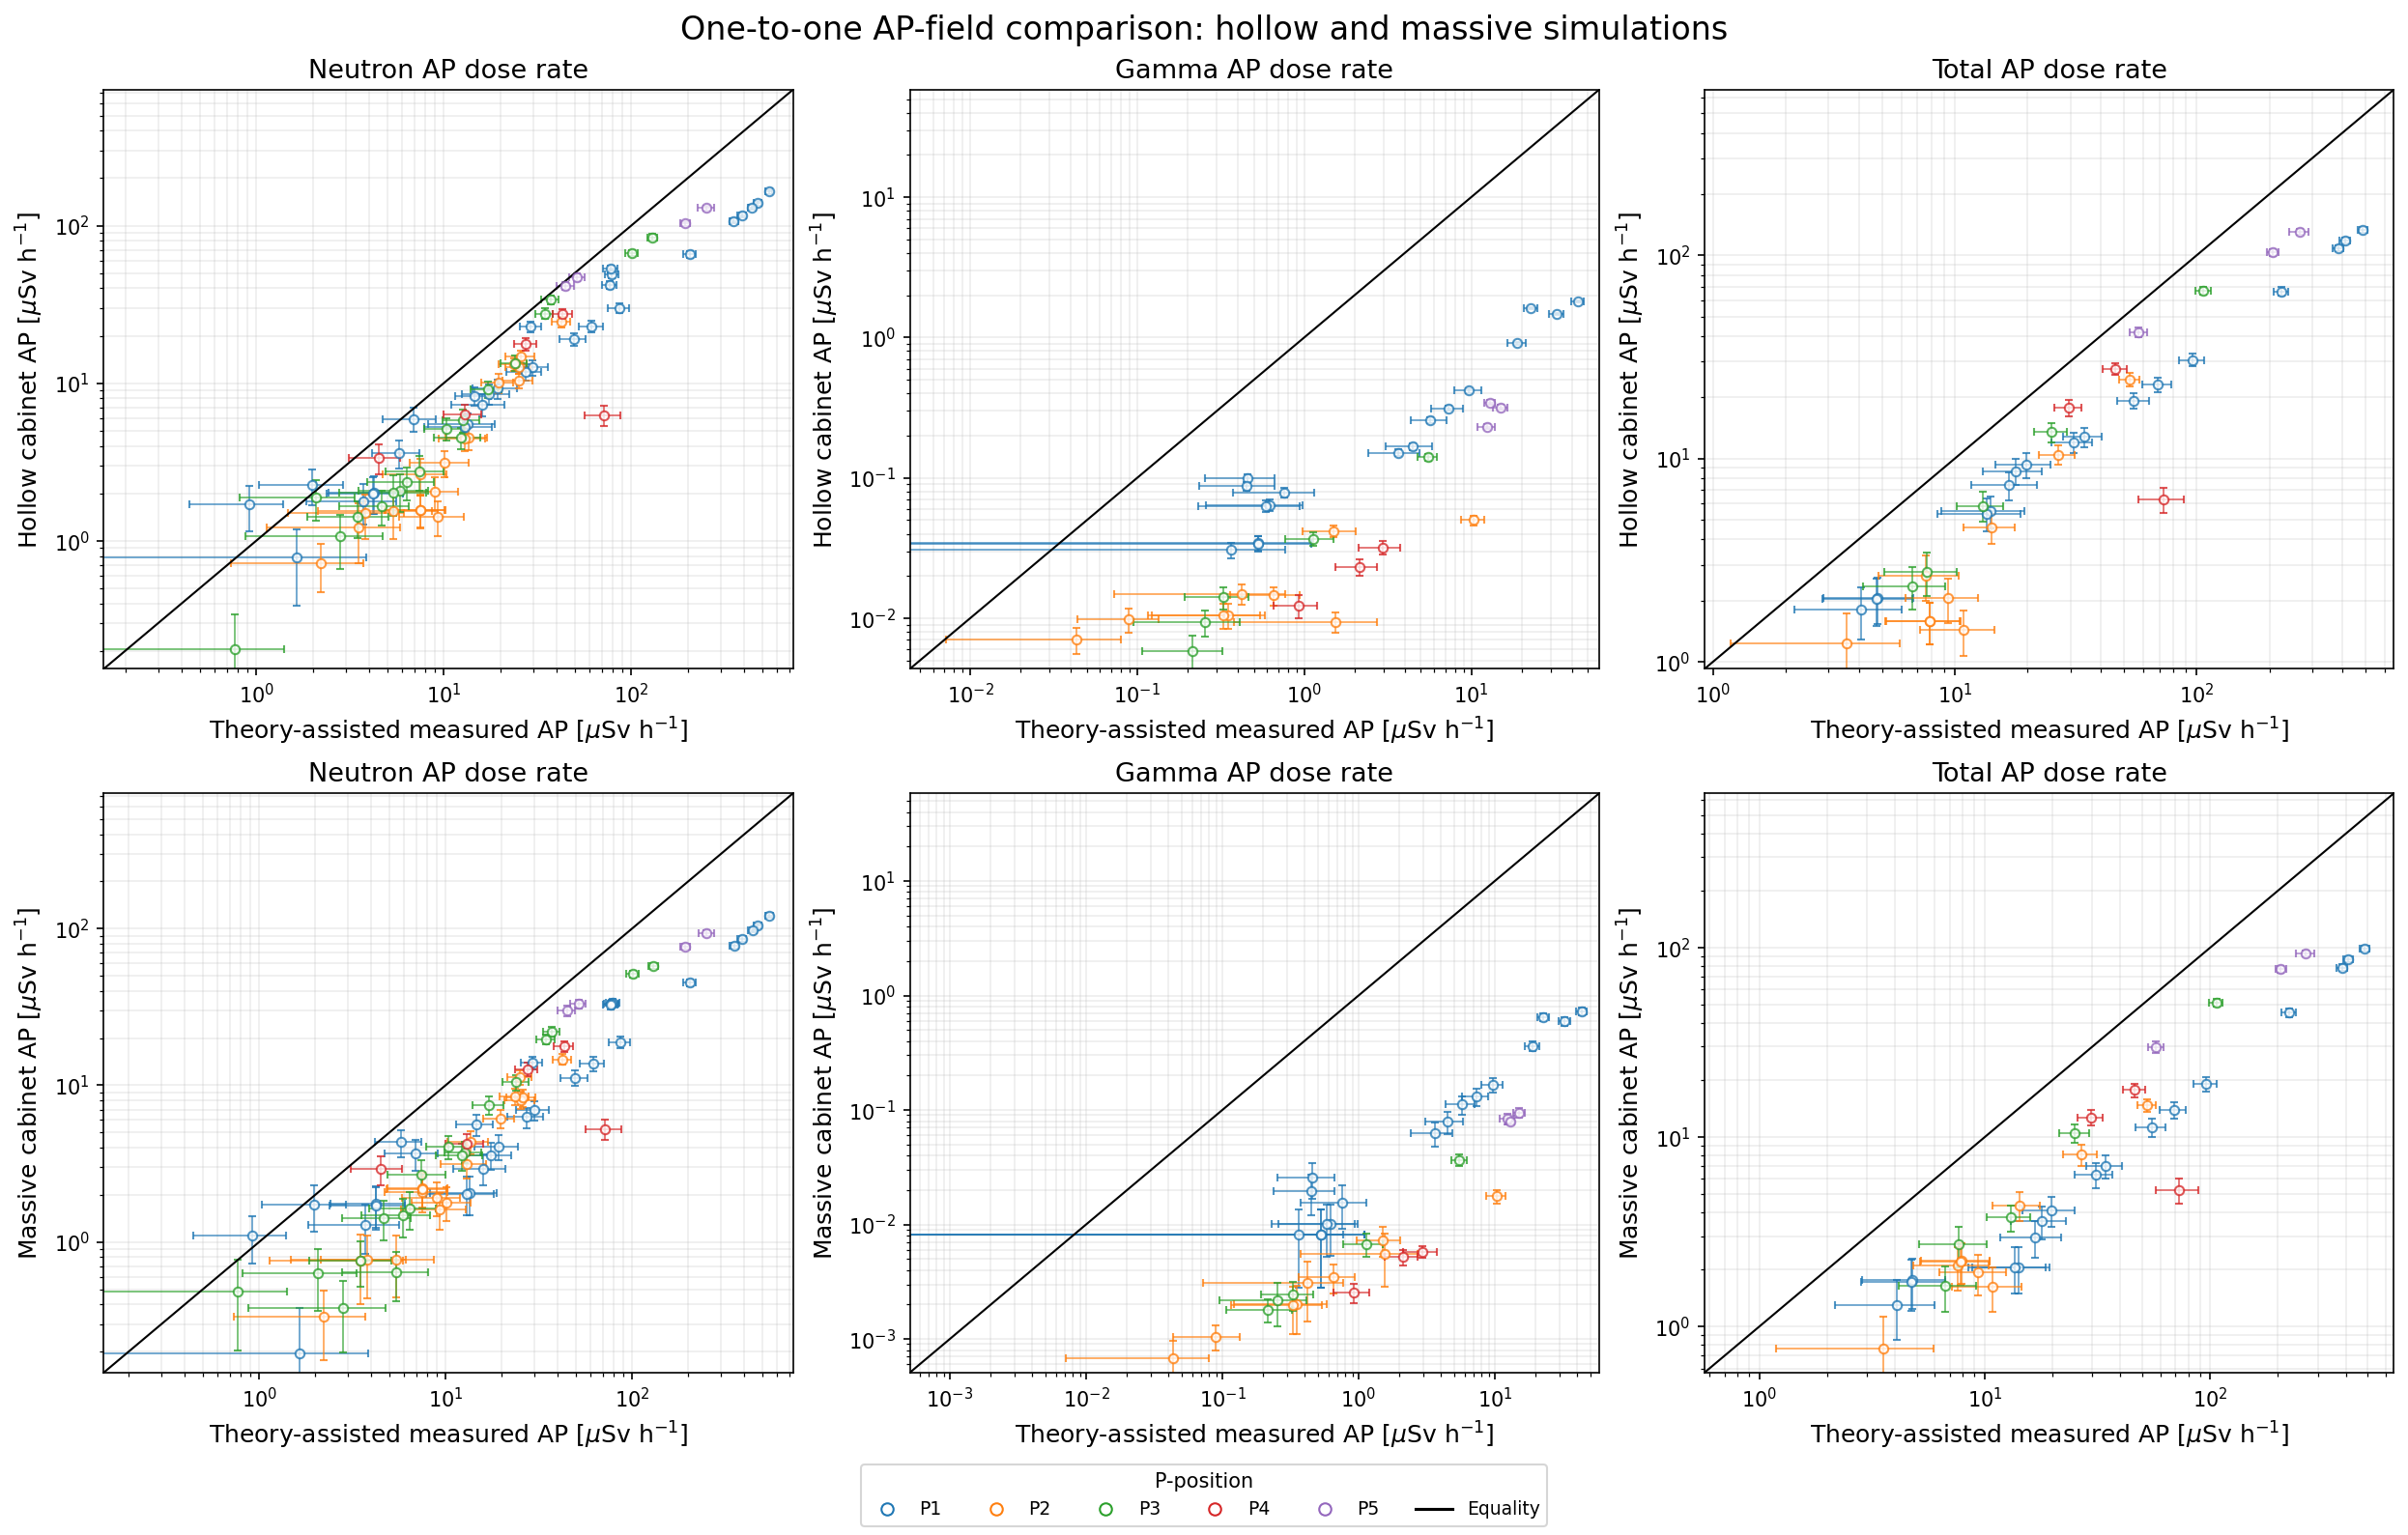

In [16]:
one_to_one_figure, one_to_one_axes = plt.subplots(
    2, 3, figsize=(16.5, 10.5), dpi=150, layout="constrained"
)

for row_index, model in enumerate(["hollow", "massive"]):
    for column_index, component in enumerate(["neutron", "gamma", "total"]):
        axis = one_to_one_axes[row_index, column_index]
        available = comparison_df[f"{model}_{component}_comparison_available"]
        data = comparison_df.loc[available]
        measured_column = COMPONENT_MEASURED_COLUMNS[component]
        measured_u_column = COMPONENT_MEASURED_U_COLUMNS[component]
        for position in POSITION_SEQUENCE:
            group = data.loc[data["position"].eq(position)]
            if group.empty:
                continue
            axis.errorbar(
                group[measured_column],
                group[f"{model}_{component}_ap_uSv_h"],
                xerr=group[measured_u_column],
                yerr=group[f"u_mc_{model}_{component}_ap_uSv_h"],
                fmt="o",
                linestyle="none",
                color=POSITION_COLORS[position],
                markerfacecolor="white",
                markeredgecolor=POSITION_COLORS[position],
                markersize=4.5,
                elinewidth=0.75,
                capsize=2.0,
                alpha=0.78,
            )
        finite_values = np.concatenate([
            data[measured_column].to_numpy(float),
            data[f"{model}_{component}_ap_uSv_h"].to_numpy(float),
        ])
        finite_values = finite_values[np.isfinite(finite_values) & (finite_values > 0.0)]
        if finite_values.size:
            lower = float(finite_values.min()) * 0.75
            upper = float(finite_values.max()) * 1.35
            axis.plot([lower, upper], [lower, upper], color="black", linewidth=1.0)
            axis.set_xlim(lower, upper)
            axis.set_ylim(lower, upper)
        axis.set_xscale("log")
        axis.set_yscale("log")
        axis.set_xlabel(r"Theory-assisted measured AP [$\mu$Sv h$^{-1}$]")
        axis.set_ylabel(rf"{MODEL_STYLES[model]['label']} AP [$\mu$Sv h$^{{-1}}$]")
        axis.set_title(COMPONENT_LABELS[component])
        axis.grid(True, which="both", alpha=0.22)

one_to_one_figure.legend(
    handles=[
        Line2D(
            [0], [0], color=POSITION_COLORS[p], marker="o", linestyle="none",
            markerfacecolor="white", label=p,
        )
        for p in POSITION_SEQUENCE
    ] + [Line2D([0], [0], color="black", label="Equality")],
    loc="outside lower center",
    ncol=6,
    title="P-position",
)
one_to_one_figure.suptitle(
    "One-to-one AP-field comparison: hollow and massive simulations",
    fontsize=16,
)
show_save_close(one_to_one_figure, "ap_one_to_one_hollow_and_massive")


# 11) Direct hollow-to-massive geometry effect

These plots remove the measured field from the ratio and therefore isolate the
change caused by the cabinet model, subject to the shared source, material,
nuclear-data, and transport assumptions. A ratio below one means the hollow
model predicts a lower AP component than the massive model at that point.


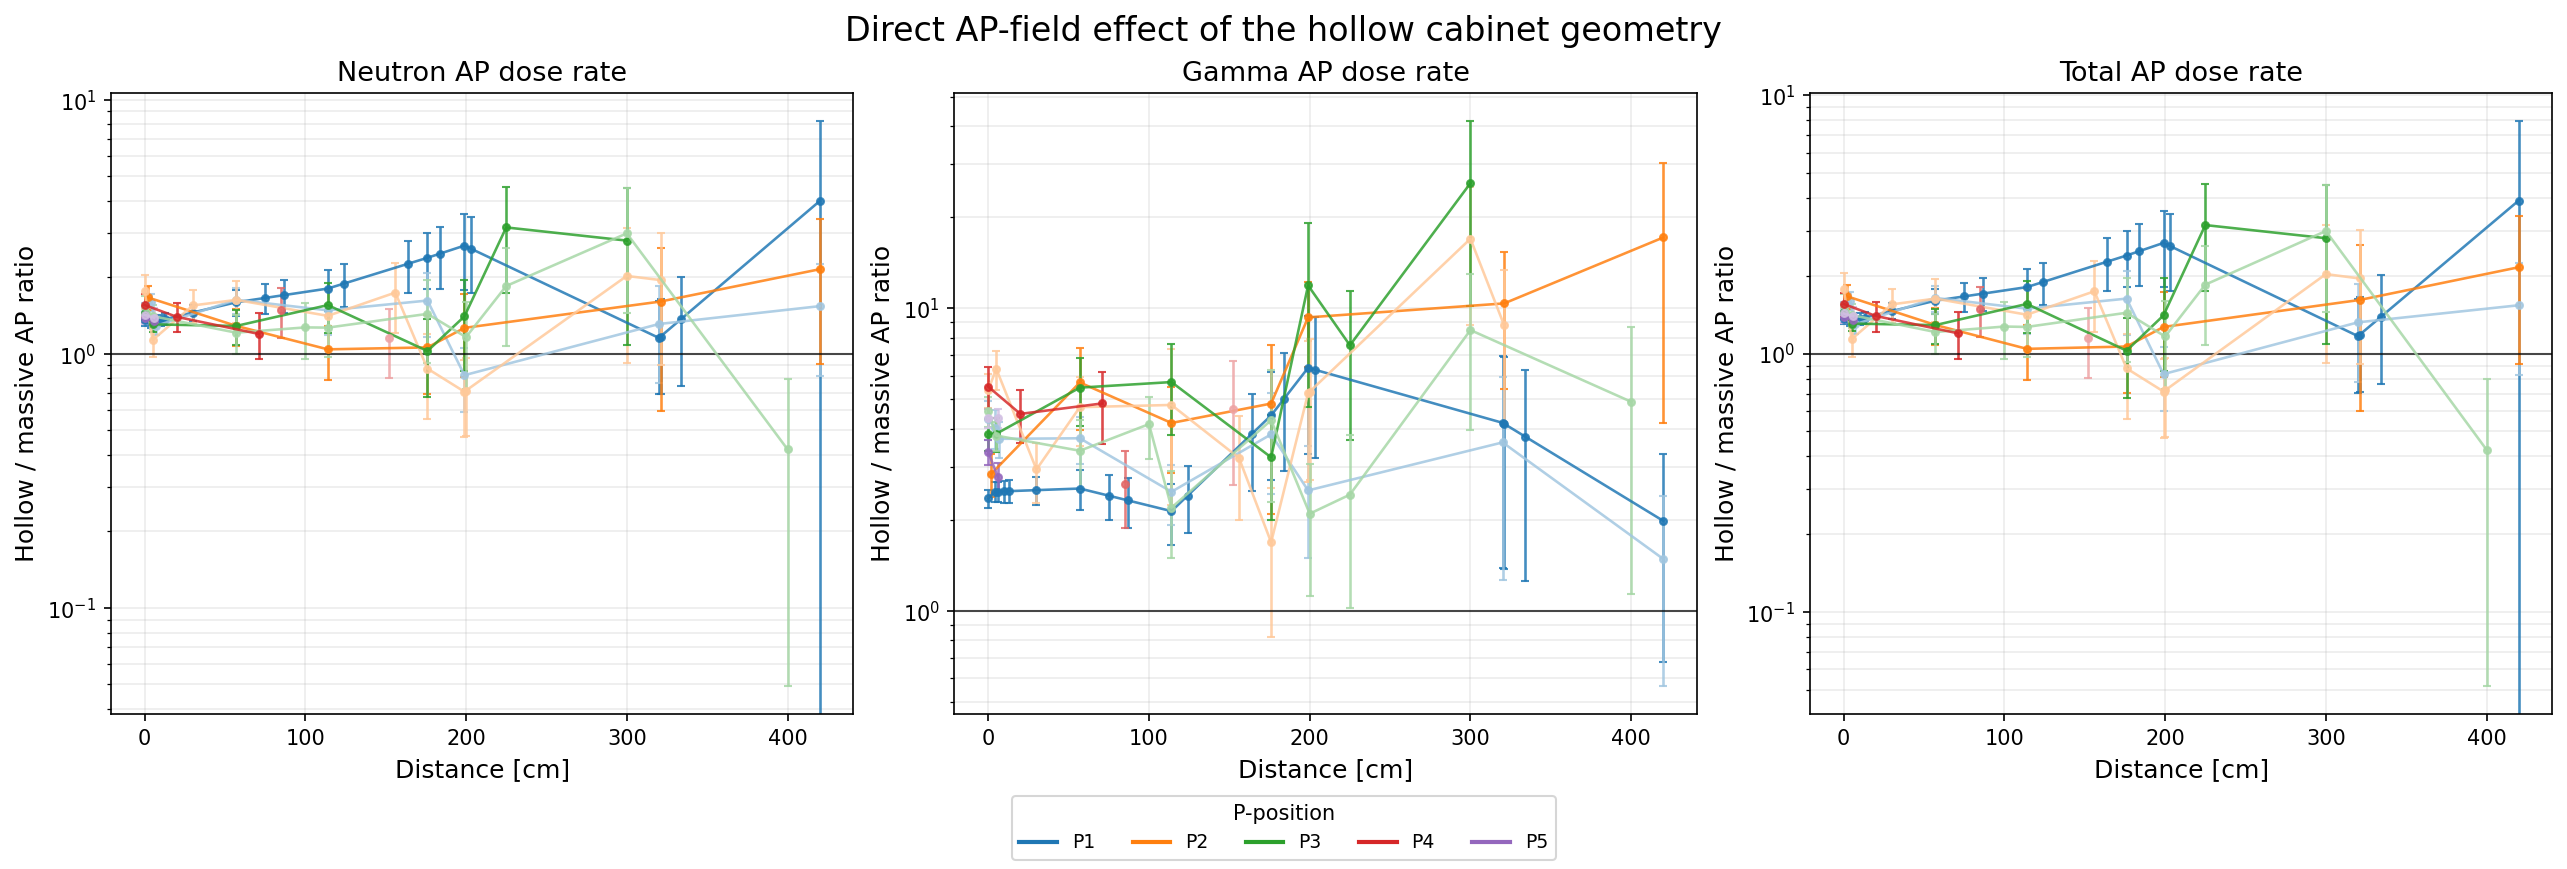

,component,position,number_of_points,geometric_mean_hollow_to_massive_ratio,median_hollow_to_massive_ratio,median_hollow_minus_massive_percent,fraction_hollow_lower_than_massive,median_mc_standard_uncertainty_of_ratio
0,neutron,P1,29,1.627631,1.540860,54.086048,0.034483,0.299698
1,neutron,P2,18,1.352218,1.480884,48.088352,0.166667,0.313665
2,neutron,P3,18,1.449048,1.406120,40.612028,0.055556,0.352032
3,neutron,P4,5,1.348473,1.398789,39.878931,0.000000,0.245645
4,neutron,P5,4,1.384972,1.386771,38.677140,0.000000,0.096190
5,gamma,P1,29,3.122537,2.537333,153.733287,0.000000,0.635962
6,gamma,P2,18,5.581278,5.276133,427.613314,0.000000,2.137901
7,gamma,P3,18,4.776862,4.207213,320.721262,0.000000,1.294311
8,gamma,P4,5,4.293440,4.640034,364.003392,0.000000,0.897803
9,gamma,P5,4,3.633882,3.842403,284.240291,0.000000,0.317349


In [17]:
geometry_effect_figure, geometry_effect_axes = plt.subplots(
    1, 3, figsize=(17.0, 5.7), dpi=150, layout="constrained"
)

for axis, component in zip(
    geometry_effect_axes, ["neutron", "gamma", "total"]
):
    for (position, height_cm), curve in comparison_df.groupby(
        ["position", "height_cm"], sort=True
    ):
        curve = curve.loc[
            curve[f"hollow_massive_{component}_comparison_available"]
        ].sort_values("distance_cm")
        if curve.empty:
            continue
        color = position_height_colors[(position, float(height_cm))]
        axis.errorbar(
            curve["distance_cm"],
            curve[f"hollow_to_massive_{component}_ratio"],
            yerr=curve[f"u_mc_hollow_to_massive_{component}_ratio"],
            color=color,
            linewidth=1.25,
            marker="o",
            markersize=3.3,
            capsize=2.0,
            alpha=0.84,
        )
    axis.axhline(1.0, color="black", linewidth=1.0, alpha=0.70)
    axis.set_yscale("log")
    axis.set_xlabel("Distance [cm]")
    axis.set_ylabel("Hollow / massive AP ratio")
    axis.set_title(COMPONENT_LABELS[component])
    axis.grid(True, which="both", alpha=0.23)

geometry_effect_figure.legend(
    handles=[
        Line2D([0], [0], color=POSITION_COLORS[p], linewidth=2.0, label=p)
        for p in POSITION_SEQUENCE
    ],
    loc="outside lower center",
    ncol=5,
    title="P-position",
)
geometry_effect_figure.suptitle(
    "Direct AP-field effect of the hollow cabinet geometry",
    fontsize=16,
)
show_save_close(geometry_effect_figure, "hollow_to_massive_component_ratios")


geometry_effect_summary_rows = []
for component in ["neutron", "gamma", "total"]:
    ratio_column = f"hollow_to_massive_{component}_ratio"
    effect_column = f"hollow_minus_massive_{component}_relative_percent"
    u_column = f"u_mc_hollow_to_massive_{component}_ratio"
    for position, group in comparison_df.groupby("position", sort=True):
        valid = np.isfinite(group[ratio_column]) & (group[ratio_column] > 0.0)
        ratios = group.loc[valid, ratio_column].astype(float)
        effects = group.loc[valid, effect_column].astype(float)
        uncertainties = group.loc[valid, u_column].astype(float)
        geometry_effect_summary_rows.append({
            "component": component,
            "position": position,
            "number_of_points": len(ratios),
            "geometric_mean_hollow_to_massive_ratio": (
                float(np.exp(np.mean(np.log(ratios)))) if len(ratios) else np.nan
            ),
            "median_hollow_to_massive_ratio": (
                float(np.median(ratios)) if len(ratios) else np.nan
            ),
            "median_hollow_minus_massive_percent": (
                float(np.median(effects)) if len(effects) else np.nan
            ),
            "fraction_hollow_lower_than_massive": (
                float(np.mean(ratios < 1.0)) if len(ratios) else np.nan
            ),
            "median_mc_standard_uncertainty_of_ratio": (
                float(np.median(uncertainties)) if len(uncertainties) else np.nan
            ),
        })

geometry_effect_summary_df = pd.DataFrame(geometry_effect_summary_rows)
display(geometry_effect_summary_df)


# 12) Spatial maps of the total-field ratios

Target heights sharing the same horizontal location are summarized by the
median $\log_{10}$ ratio. The diverging colour scale is centred at zero, so
white denotes equality, red denotes a numerator above the denominator, and
blue denotes a numerator below the denominator.


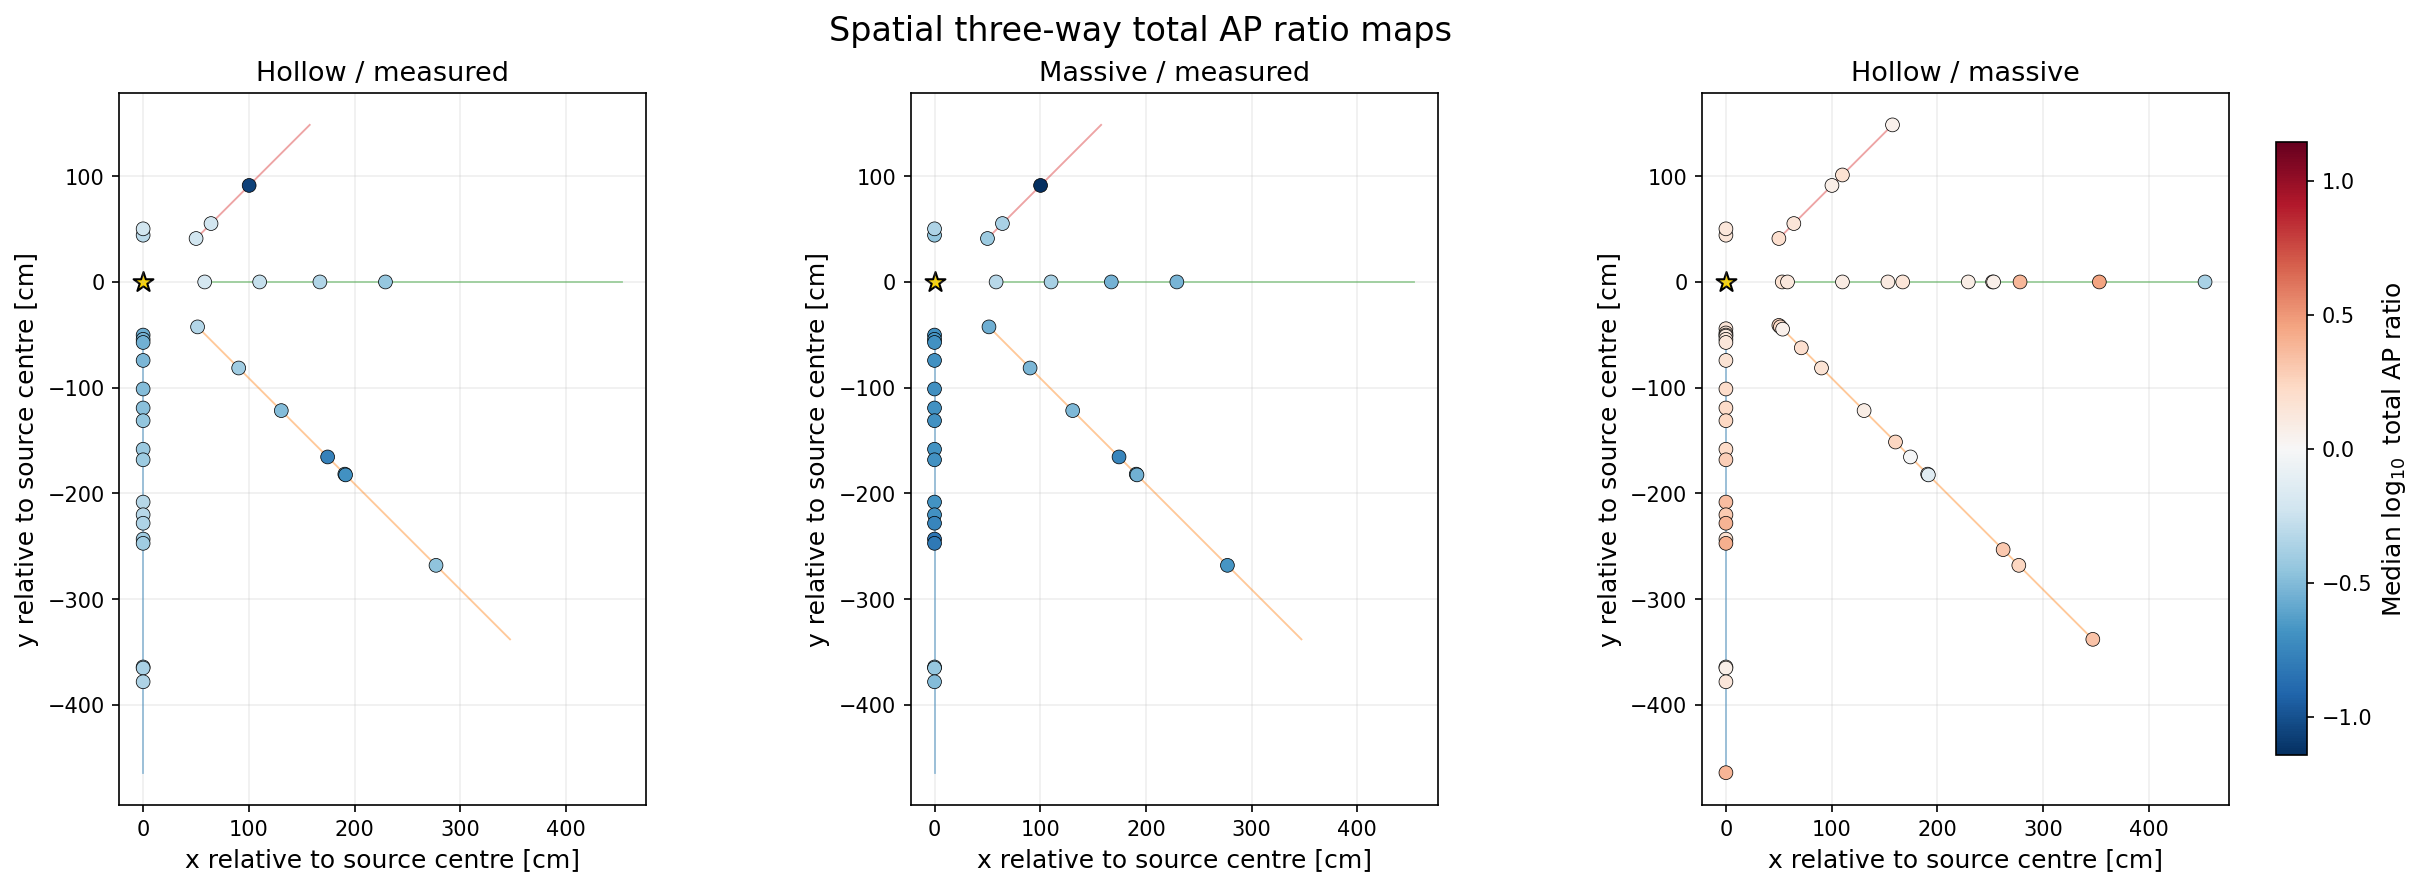

,position,distance_cm,common_dose_x_cm,common_dose_y_cm,median_log10_ratio,represented_target_heights,comparison
0,P1,0.0,0.0,-44.25,NaN,"42, 85",Hollow / measured
1,P1,4.0,0.0,-48.25,NaN,"42, 85",Hollow / measured
2,P1,6.0,0.0,-50.25,-0.562712,42,Hollow / measured
3,P1,7.0,0.0,-51.25,NaN,85,Hollow / measured
4,P1,10.0,0.0,-54.25,-0.541160,42,Hollow / measured
5,P1,13.0,0.0,-57.25,-0.550448,42,Hollow / measured
6,P1,30.0,0.0,-74.25,-0.526944,42,Hollow / measured
7,P1,57.0,0.0,-101.25,-0.497548,"42, 85",Hollow / measured
8,P1,75.0,0.0,-119.25,-0.473646,42,Hollow / measured
9,P1,87.0,0.0,-131.25,-0.455067,42,Hollow / measured


In [18]:
spatial_ratio_definitions = {
    "Hollow / measured": "log10_hollow_to_measured_total_ratio",
    "Massive / measured": "log10_massive_to_measured_total_ratio",
    "Hollow / massive": "log10_hollow_to_massive_total_ratio",
}

spatial_summary_frames = []
for label, ratio_column in spatial_ratio_definitions.items():
    frame = (
        comparison_df
        .groupby(
            ["position", "distance_cm", "common_dose_x_cm", "common_dose_y_cm"],
            dropna=False,
        )
        .agg(
            median_log10_ratio=(ratio_column, "median"),
            represented_target_heights=(
                "height_cm",
                lambda values: ", ".join(
                    f"{value:g}" for value in np.sort(values.unique())
                ),
            ),
        )
        .reset_index()
    )
    frame["comparison"] = label
    spatial_summary_frames.append(frame)

spatial_ratio_summary_df = pd.concat(spatial_summary_frames, ignore_index=True)
finite_spatial_values = spatial_ratio_summary_df["median_log10_ratio"].to_numpy(float)
finite_spatial_values = finite_spatial_values[np.isfinite(finite_spatial_values)]
color_limit = (
    max(0.30103, float(np.nanmax(np.abs(finite_spatial_values))))
    if finite_spatial_values.size else 0.30103
)
spatial_norm = Normalize(vmin=-color_limit, vmax=color_limit)

spatial_figure, spatial_axes = plt.subplots(
    1, 3, figsize=(17.0, 5.8), dpi=150, layout="constrained"
)

last_scatter = None
for axis, (label, _) in zip(spatial_axes, spatial_ratio_definitions.items()):
    data = spatial_ratio_summary_df.loc[
        spatial_ratio_summary_df["comparison"].eq(label)
    ]
    for position in POSITION_SEQUENCE:
        path = data.loc[data["position"].eq(position)].sort_values("distance_cm")
        if not path.empty:
            axis.plot(
                path["common_dose_x_cm"],
                path["common_dose_y_cm"],
                color=POSITION_COLORS[position],
                linewidth=0.9,
                alpha=0.42,
            )
    last_scatter = axis.scatter(
        data["common_dose_x_cm"],
        data["common_dose_y_cm"],
        c=data["median_log10_ratio"],
        cmap="RdBu_r",
        norm=spatial_norm,
        s=44,
        edgecolor="black",
        linewidth=0.35,
        zorder=3,
    )
    axis.scatter([0.0], [0.0], marker="*", s=100, color="gold", edgecolor="black")
    axis.set_aspect("equal", adjustable="box")
    axis.set_xlabel("x relative to source centre [cm]")
    axis.set_ylabel("y relative to source centre [cm]")
    axis.set_title(label)
    axis.grid(True, alpha=0.20)

if last_scatter is not None:
    colorbar = spatial_figure.colorbar(
        last_scatter,
        ax=spatial_axes,
        shrink=0.86,
        pad=0.02,
    )
    colorbar.set_label(r"Median $\log_{10}$ total AP ratio")

spatial_figure.suptitle("Spatial three-way total AP ratio maps", fontsize=16)
show_save_close(spatial_figure, "spatial_three_way_total_ap_ratios")
display(spatial_ratio_summary_df.head(12))


# 13) Export final tables, figures, and method metadata

The common-grid table is the complete numerical hand-off. Compact summary
tables support traceability, while the report-facing results are the saved PNG
and PDF figures.


In [19]:
table_outputs = {
    "hollow_vs_measurement_vs_massive_common_grid_final.csv": comparison_df,
    "comparison_coverage_summary.csv": coverage_summary_df,
    "three_way_ratio_summary.csv": ratio_summary_df,
    "central_agreement_gain_summary.csv": agreement_gain_summary_df,
    "hollow_vs_massive_geometry_effect_summary.csv": geometry_effect_summary_df,
    "spatial_total_ratio_summary.csv": spatial_ratio_summary_df,
    "comparison_methodology_audit.csv": methodology_audit_df,
    "input_audit.csv": input_audit_df,
    "simulation_coordinate_alignment_audit.csv": coordinate_alignment_df,
}

for filename, dataframe in table_outputs.items():
    dataframe.to_csv(TABLE_DIR / filename, index=False)

figure_inventory_df = pd.DataFrame(exported_figure_rows)
figure_inventory_path = METADATA_DIR / "h3_figure_inventory.csv"
figure_inventory_df.to_csv(figure_inventory_path, index=False)

metadata_df = pd.DataFrame([
    {
        "quantity": "notebook",
        "value": "3H_Hollow_vs_measurement_vs_massiv.ipynb",
        "note": "final three-way H-series comparison",
    },
    {
        "quantity": "hollow_input",
        "value": str(HOLLOW_INPUT_PATH.resolve()),
        "note": "Notebook 2H physical AP field",
    },
    {
        "quantity": "massive_input",
        "value": str(MASSIVE_INPUT_PATH.resolve()),
        "note": "original Notebook 3 physical AP field",
    },
    {
        "quantity": "measured_input",
        "value": str(MEASURED_INPUT_PATH.resolve()),
        "note": "Notebook 5 theory-assisted measured AP field",
    },
    {
        "quantity": "metadata_compatibility_status",
        "value": metadata_compatibility_status,
        "note": "source/date/AP checks when metadata are available",
    },
    {
        "quantity": "shared_simulation_nodes",
        "value": len(coordinate_alignment_df),
        "note": "same nominal P-position, distance, and target height",
    },
    {
        "quantity": "maximum_common_coordinate_difference_cm",
        "value": maximum_coordinate_delta_cm,
        "note": "must be at or below matching tolerance",
    },
    {
        "quantity": "simulation_interpolation",
        "value": "positive log-linear within same P and exact target height",
        "note": "no extrapolation",
    },
    {
        "quantity": "measurement_dependence",
        "value": "Notebook 5 AP field uses massive Notebook 3 conversion factors",
        "note": "simulation-to-measurement comparison is not independent",
    },
    {
        "quantity": "hollow_massive_ratio_uncertainty",
        "value": "quadrature of relative OpenMC batch standard uncertainties",
        "note": "statistically independent simulation-run assumption",
    },
    {
        "quantity": "reported_uncertainty_scope",
        "value": "displayed component uncertainties; no combined independent z score",
        "note": "model/source/material/nuclear-data covariance unavailable",
    },
])
metadata_path = METADATA_DIR / "h3_analysis_metadata.csv"
metadata_df.to_csv(metadata_path, index=False)

analysis_summary = {
    "notebook": "3H_Hollow_vs_measurement_vs_massiv.ipynb",
    "comparison_grid_rows": int(len(comparison_df)),
    "three_way_total_comparisons": int(
        (
            comparison_df["hollow_total_comparison_available"]
            & comparison_df["massive_total_comparison_available"]
        ).sum()
    ),
    "shared_simulation_nodes": int(len(coordinate_alignment_df)),
    "maximum_coordinate_difference_cm": maximum_coordinate_delta_cm,
    "figures": int(len(figure_inventory_df)),
    "primary_table": str(
        (TABLE_DIR / "hollow_vs_measurement_vs_massive_common_grid_final.csv").resolve()
    ),
    "interpretation": (
        "model-assisted consistency comparison; direct hollow/massive ratio "
        "isolates the cabinet-geometry change within shared model assumptions"
    ),
}
summary_path = METADATA_DIR / "h3_analysis_summary.json"
summary_path.write_text(json.dumps(analysis_summary, indent=2), encoding="utf-8")

print("Saved final Notebook 3H outputs:")
print(f"  Primary table: {analysis_summary['primary_table']}")
print(f"  Metadata:      {metadata_path}")
print(f"  Summary:       {summary_path}")
print(f"  Figures:       {len(figure_inventory_df)} PNG/PDF pairs")
display(metadata_df)


Saved final Notebook 3H outputs:
  Primary table: /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/H3_hollow_vs_measurement_vs_massive_outputs/tables/hollow_vs_measurement_vs_massive_common_grid_final.csv
  Metadata:      /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/H3_hollow_vs_measurement_vs_massive_outputs/metadata/h3_analysis_metadata.csv
  Summary:       /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/H3_hollow_vs_measurement_vs_massive_outputs/metadata/h3_analysis_summary.json
  Figures:       9 PNG/PDF pairs


,quantity,value,note
0,notebook,3H_Hollow_vs_measurement_vs_massiv.ipynb,final three-way H-series comparison
1,hollow_input,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/H2_hollow_cabinet_unified_outputs/tables/hollow_unified_simulated_radiation_field_final.csv,Notebook 2H physical AP field
2,massive_input,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N3_simulated_unified_outputs/tables/unified_simulated_radiation_field_final.csv,original Notebook 3 physical AP field
3,measured_input,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N5_unified_measured_outputs/tables/measured_total_ap_field_common_grid_final.csv,Notebook 5 theory-assisted measured AP field
4,metadata_compatibility_status,"source normalization, evaluation date, and AP geometry matched",source/date/AP checks when metadata are available
5,shared_simulation_nodes,61,"same nominal P-position, distance, and target height"
6,maximum_common_coordinate_difference_cm,0.0,must be at or below matching tolerance
7,simulation_interpolation,positive log-linear within same P and exact target height,no extrapolation
8,measurement_dependence,Notebook 5 AP field uses massive Notebook 3 conversion factors,simulation-to-measurement comparison is not independent
9,hollow_massive_ratio_uncertainty,quadrature of relative OpenMC batch standard uncertainties,statistically independent simulation-run assumption


## 13.1 Quantify how the hollow geometry agrees with measurements

In [20]:
# Quantify how much better the hollow geometry agrees with measurements
# using Notebook 3H's multiplicative/logarithmic agreement metric.

valid = (
    comparison_df["hollow_total_comparison_available"].astype(bool)
    & comparison_df["massive_total_comparison_available"].astype(bool)
)

hollow_ratio = pd.to_numeric(
    comparison_df.loc[valid, "hollow_to_measured_total_ratio"],
    errors="coerce",
).to_numpy(dtype=float)

massive_ratio = pd.to_numeric(
    comparison_df.loc[valid, "massive_to_measured_total_ratio"],
    errors="coerce",
).to_numpy(dtype=float)

finite = (
    np.isfinite(hollow_ratio)
    & np.isfinite(massive_ratio)
    & (hollow_ratio > 0.0)
    & (massive_ratio > 0.0)
)

hollow_ratio = hollow_ratio[finite]
massive_ratio = massive_ratio[finite]

hollow_log_error = np.mean(np.abs(np.log10(hollow_ratio)))
massive_log_error = np.mean(np.abs(np.log10(massive_ratio)))

hollow_improvement_percent = (
    100.0
    * (massive_log_error - hollow_log_error)
    / massive_log_error
)

hollow_closer_fraction = 100.0 * np.mean(
    np.abs(np.log10(hollow_ratio))
    < np.abs(np.log10(massive_ratio))
)

print(f"Common comparison points:             {len(hollow_ratio)}")
print(f"Hollow mean absolute log10 error:     {hollow_log_error:.6f}")
print(f"Massive mean absolute log10 error:    {massive_log_error:.6f}")
print(f"Hollow agreement improvement:         {hollow_improvement_percent:.2f}%")
print(f"Hollow geometry closer at:            {hollow_closer_fraction:.1f}% of points")

Common comparison points:             37
Hollow mean absolute log10 error:     0.443171
Massive mean absolute log10 error:    0.599936
Hollow agreement improvement:         26.13%
Hollow geometry closer at:            91.9% of points


# 14) Summary, interpretation, and limitations

Notebook 3H compares the final hollow-cabinet and original massive-cabinet
OpenMC fields with the same Notebook 5 theory-assisted measured field. Neutron,
gamma, and total AP components remain visible throughout, and both simulations
are evaluated only inside their valid support on the same P-position and exact
target-height curves.

The hollow-to-measured and massive-to-measured ratios describe central
consistency. They are not independent validation statistics because Notebook 5
uses conversion information from the massive simulation. The agreement-gain
plots therefore answer only whether the hollow central prediction moves closer
to the measured estimate on a multiplicative scale; they do not establish
statistical superiority.

The direct hollow-to-massive ratios provide the clearest estimate of the
geometry change. Their error bars cover independent OpenMC batch statistics
only. They exclude common or correlated uncertainty from source normalization,
ALPHANSO yields and spectra, wall dimensions, material composition, nuclear
data, detector response, measurement positioning, and the experimental
uncertainty model.
